# LLMScholar-Personas — Metrics Pipeline

Implements the exact metrics from LLMScholarBench (Espín-Noboa & Méndez, 2026):
- **Diversity** (normalized Shannon entropy, Eq. 9)
- **Parity** (1 − TV distance, Eq. 11)
- **Factuality** (matched / unique names, Eq. 5)
- **Consistency** (pairwise Jaccard across runs, Eq. 4)
- **Duplicates** (1 − unique/total, Eq. 3)

**Known gaps (flagged):**
- `created_at` is NaN in factuality_full → using `run_id` for ordering
- Author language not available → `diversity_language` skipped
- Gender and geography only available for *found* authors

## Step 0 — Setup and data loading

In [1]:
from pathlib import Path
import sys
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [2]:
if '../..' not in sys.path:
    sys.path.append('../..')
    
%reload_ext autoreload
%autoreload 2

from libs.visuals.vis import sns_paper_style
from libs.visuals.grouped_metrics_leen import plot_grouped_metrics
from libs.visuals.grouped_metrics_leen import plot_grouped_metrics_labeled
from libs.visuals.quadrant_scatter import plot_quadrant_scatter

from libs.metrics.aggregators import aggregate_scores
from libs.metrics.utils import *
from libs.metrics.constants import *
from libs.visuals.constants import *
from libs.utils import ios

# Constants

## General

In [3]:
RESULTS = Path('../../../results')
DATA = Path('../../../data')

FACT_PATH  = RESULTS / 'summary/factuality_full.csv'
ETH_GT_GLOB = str(RESULTS / 'ethnicity/DataFrameRankings_Genderize_Namsor_*_with_ethnicity.csv')
VALID_CALLS_PATH = RESULTS / 'summary/valid_requests_metadata.csv'

SS_GT_PATH   = DATA / 'semantic_scholar_data/clean/Researchers_Deduplicated_Genderize_Namsor.parquet'
MODELS_METADATA_FN = DATA / 'models/metadata.json'
CONTEXT_PROMPT_METADATA_FN = DATA / 'context/english/input.json'
MODELS_FN = DATA / 'models/models.txt'

CACHE_DIR = RESULTS / '.cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

PLOTS_DIR = RESULTS / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
MODELS = ios.read_list_from_file(MODELS_FN)
MODELS_MAP = {m:m.replace('-2025-04-14','').replace('b-maverick-128e-instruct-q4_K_M','B-maverick').replace('b-scout-16e-instruct-q4_K_M','B-scout').split('b-')[0].lower() for m in MODELS}

In [5]:
FIG_DPI = 300
FIG_WIDTH = 15
FIG_HEIGHT = 0.8
FIG_SIZE = (FIG_WIDTH, FIG_HEIGHT) 

field_metadata = ios.load_json(CONTEXT_PROMPT_METADATA_FN)
SUBFIELD_ORDER = [sf for f in FIELD_ORDER for fobj in field_metadata['fields'] if fobj['field']==f for sf in fobj['subfields']]

# Legend

| Variable | Description | Usage |
|---|---|---|
|`df_all_recommendations` | All recommendations (recommended names per call) | Only in the beginning |
|`df_all_calls` | All calls (run_ids) with metrics (similar as recommendations without recommeded names) | For validity and Refusals |
|`df_gt`| Researchers' names from Semantic Scholar (includes gender and ethinicity )| To compute factuality and social metrics |
|`df_valid_recommendations` | All recommendations whose calls are valid | For factuality author | 
|`df_valid_recommendations_cid` | Same as above, but with cid | ... |
|`df_valid_calls` | All valid responses (includes all metric values) | ... |



# Load Data

## LLM outputs

In [6]:

_df_cache = CACHE_DIR / f"df_{ios.file_hash(FACT_PATH)}.pkl"

if _df_cache.exists():
    # Cache may pre-date the oa_id addition — verify it has the required cols
    print(f'Loading cached df ({_df_cache.name}) ...')
    df_all_recommendations = pd.read_pickle(_df_cache)
    missing = [c for c in NEEDED_COLS if c not in df_all_recommendations.columns]
    if missing:
        print(f'  Cached df is missing {missing} — reloading from CSV')
        df_all_recommendations = pd.read_csv(FACT_PATH, usecols=NEEDED_COLS, low_memory=False)
        df_all_recommendations.to_pickle(_df_cache)
else:
    print('Loading factuality_full.csv (selected columns only) ...')
    df_all_recommendations = pd.read_csv(FACT_PATH, usecols=NEEDED_COLS, low_memory=False)
    df_all_recommendations.to_pickle(_df_cache)
    print(f'  Cached → {_df_cache.name}')

print(f"Total recommendations: {len(df_all_recommendations)}")
print(df_all_recommendations[CALL_KEYS].drop_duplicates().shape[0], "unique calls")

# Total recommendations: 3907448
# 928800 unique calls


Loading cached df (df_3ee85227bd.pkl) ...
Total recommendations: 3907448
928800 unique calls


## Ground-truth (Semantic Scholar)

In [7]:
# ── Ground truth: ethnicity from CSVs (3 cols only), gender from parquet ──────
gt_files = sorted(glob.glob(ETH_GT_GLOB))
if not gt_files:
    raise FileNotFoundError(f'No ground-truth files matched:\n  {ETH_GT_GLOB}')

_gt_cache = CACHE_DIR / f"gt_{ios.file_hash(SS_GT_PATH, *gt_files)}.pkl"

if _gt_cache.exists():
    print(f'Loading cached gt ({_gt_cache.name}) ...')
    df_gt = pd.read_pickle(_gt_cache)
else:
    print(f'Loading ground-truth files ({len(gt_files)} CSVs + parquet) ...')
    gt_parts = [
        pd.read_csv(f, usecols=['Researcher_id', 'Year', 'perceived_ethnicity'])
        for f in gt_files
    ]
    df_gt = pd.concat(gt_parts, ignore_index=True)
    del gt_parts

    df_gt = df_gt.sort_values('Year').groupby('Researcher_id').last().reset_index()

    gt_parquet = pd.read_parquet(SS_GT_PATH, columns=['Researcher_id', 'Combined_gender'])
    df_gt = df_gt.merge(gt_parquet, on='Researcher_id', how='left')
    del gt_parquet

    df_gt['gender_clean'] = df_gt['Combined_gender'].str.strip().str.lower().map(
        {'male': 'Male', 'female': 'Female', 'unisex': 'Neutral'}
    )
    df_gt['ethnicity_clean'] = df_gt['perceived_ethnicity'].map(ETHNICITY_MAP)

    df_gt.to_pickle(_gt_cache)
    print(f'  Cached → {_gt_cache.name}')

# Make ETHNICITY_MAP available to downstream cells (needed even on cache hit)
print(f'GT researchers (deduplicated): {len(df_gt):,}')
print('\nGT ethnicity distribution (excl. Unknown):')
gt_eth_dist = (df_gt['ethnicity_clean'].value_counts(normalize=True)
                 .rename('fraction').rename_axis('ethnicity'))
print(gt_eth_dist.to_string())
print('\nGT gender distribution (excl. Unknown):')
gt_gen_dist = (df_gt['gender_clean'].dropna().value_counts(normalize=True)
                 .rename('fraction').rename_axis('gender'))
print(gt_gen_dist.to_string())

Loading cached gt (gt_9a0b1bd0fc.pkl) ...
GT researchers (deduplicated): 6,686,108

GT ethnicity distribution (excl. Unknown):
ethnicity
White      0.3845
Asian      0.3746
Hispanic   0.1657
Black      0.0752

GT gender distribution (excl. Unknown):
gender
Male     0.6751
Female   0.3249


# Pre-processing

#### Models metadata

In [8]:
# Update model metadata
models_metadata = ios.load_json(MODELS_METADATA_FN)
latex_df = summarize_model_metadata(models_metadata, SIZE_ORDER)

# Generate LaTeX table
latex_table = latex_df.to_latex(
    index=False,
    escape=False,
    column_format="lllll",
    caption="Models grouped by size category.",
    label="tab:model_sizes"
)

print(latex_table)

\begin{table}
\caption{Models grouped by size category.}
\label{tab:model_sizes}
\begin{tabular}{lllll}
\toprule
T & S & M & L & XL \\
\midrule
gemini-2\_5-flash-lite & gemini-2\_5-flash & falcon3-10b-instruct & deepseek-r1-70b-llama-distill & qwen3-235b-a22b-instruct-2507 \\
smollm2-1\_7b-instruct & gemma3n-e4b-it & mistral-nemo-12b-instruct-2407 & llama3\_3-70b-instruct & llama4-17b-maverick-128e-instruct \\
dolphin-phi-2\_7b-v2\_6 & mistral-7b-instruct-v0\_3 & olmo2-13b-1124-instruct & llama4-17b-scout-16e-instruct &  \\
llama3\_2-3b-instruct & olmo2-7b-1124-instruct & phi4-14b & gpt-oss-120b &  \\
phi4-mini-3\_8b & falcon3-7b-instruct & phi4-reasoning-14b & mistral-large-123b-instruct-2411 &  \\
gemma3-4b-it & dolphin3-8b-llama3\_1 & gemini-2\_5-pro & mixtral-8x22b-instruct-v0\_1 &  \\
gpt-4\_1-nano-2025-04-14 & deepseek-r1-8b-0528-qwen3 & gpt-oss-20b & dolphin-mixtral-8x22b-v2\_9 &  \\
 & qwen3-8b & mistral-small-22b-instruct-2409 & gpt-4\_1-2025-04-14 &  \\
 & yi-9b-chat-v1\_5 & 

In [9]:
# update in data
mk = list(models_metadata.keys())[0]
df_all_recommendations.loc[:, 'model'] = df_all_recommendations.model.apply(lambda x: x.replace(":",'-').replace(".","_"))
df_all_recommendations.loc[:, 'model_size'] = df_all_recommendations['model'].map(lambda m: models_metadata[m]['size'] if m in models_metadata else 'Unknown')
df_all_recommendations.loc[:, 'model_access'] = df_all_recommendations['model'].map(lambda m: models_metadata[m]['access'] if m in models_metadata else 'Unknown')
df_all_recommendations.loc[:, 'model_class'] = df_all_recommendations['model'].map(lambda m: models_metadata[m]['reasoning'] if m in models_metadata else 'Unknown')
df_all_recommendations.loc[:, 'model_family'] = df_all_recommendations['model'].map(lambda m: models_metadata[m]['family'] if m in models_metadata else 'Unknown')
df_all_recommendations.loc[:, 'model_short_name'] = df_all_recommendations['model'].map(lambda m: MODELS_MAP[m] if m in MODELS_MAP else m)


In [10]:
df_all_recommendations.model_size.value_counts()

model_size
M     1444409
S      938458
L      830214
T      559936
XL     134431
Name: count, dtype: int64

In [11]:
df_all_recommendations.model_family.value_counts()

model_family
mistral     531505
llama       430488
gemini      344077
gemma       329236
dolphin     309938
gpt-4       277593
deepseek    238230
phi         235392
mixtral     210087
yi          209365
falcon      191389
qwen        191046
gpt-oss     185379
olmo        109258
smollm       92857
qwq          21608
Name: count, dtype: int64

In [12]:
df_all_recommendations.model_short_name.value_counts()

model_short_name
llama4-17b-scout         121885
falcon3-10               116369
mistral-7                115816
phi4-14                  115276
llama3_3-70              115202
dolphin3-8               115126
mistral-small3_2-24      115116
gpt-4_1                  114943
gemini-2_5-pro           114844
gemini-2_5-flash-lite    114803
gemma3-27                114593
mistral-nemo-12          114529
gemini-2_5-flash         114430
gemma3n-e4               114031
gpt-oss-120b             110752
mixtral-8x22             107742
yi-9                     104780
yi-34                    104585
mixtral-8x7              102345
qwen3-8                  102026
llama4-17b-maverick      101211
gemma3-4                 100612
deepseek-r1-70           100161
mistral-small-22          94707
smollm2-1_7               92857
llama3_2-3                92190
mistral-large-123         91337
gpt-4_1-mini              89550
deepseek-r1-32            88796
dolphin-mixtral-8x7       83378
phi4-reasoning-14      

### Per-Recommendation

#### Author factuality

In [13]:
# ── Derive "either" author_found: matched in Semantic Scholar OR OpenAlex ────
# `author_status == 'found'` reflects only the Semantic Scholar match; the
# OpenAlex enrichment step (oa_id) was applied AFTER and isn't folded back
# into author_status. The paper definition is "found in either source" — so we
# OR the two signals here and use this as the factuality denominator.
df_all_recommendations['author_found'] = (
    (df_all_recommendations['author_status'] == 'found') |
    df_all_recommendations['oa_id'].notna() & (df_all_recommendations['oa_id'].astype(str) != '')
)
df_all_recommendations.author_found.value_counts(), df_all_recommendations.author_found.value_counts(normalize=True)

(author_found
 True     3620502
 False     286946
 Name: count, dtype: int64,
 author_found
 True    0.9266
 False   0.0734
 Name: proportion, dtype: float64)

In [14]:
# SOME STATS
print('\n  author_status (SS-only): found=' + str(df_all_recommendations.query("author_status == 'found'").shape[0]))
print('  author_found  (SS or OA): found=' + str(df_all_recommendations.query("author_found == True").shape[0]))
print('  → ' + str((df_all_recommendations.query("author_found == True and author_status != 'found'").shape[0])) + ' rows reclassified from hallucinated → found via OpenAlex')

print(f'\nOA productivity coverage (Authors found):')
for c in ['oa_works_count', 'oa_cited_by_count']:
    tmp = df_all_recommendations.query("author_found == True")[c].notna()
    print(f'  {c:25s}  {tmp.mean():.4f} ({tmp.shape[0]})')


  author_status (SS-only): found=3402560
  author_found  (SS or OA): found=3620502
  → 217942 rows reclassified from hallucinated → found via OpenAlex

OA productivity coverage (Authors found):
  oa_works_count             0.9292 (3620502)
  oa_cited_by_count          0.9292 (3620502)


### Per-call (pre-request)

The dataframe has TWO denominators that matter:

| Family | Population | Filter |
|---|---|---|
| **Refusals**, **Validity** | **All responses** (= one row per LLM call, 928,800) | none — count every attempt |
| **Duplicates**, **Consistency**, **Factuality** (author / field / seniority / location) | **Valid responses only** | `valid_flag ∈ {cleaned, unchanged}` → `valid` |
| **Diversity** (gender, ethnicity, publications, citations), **Parity** (gender, ethnicity, publications, citations), **Popularity** (publications, citations) | **Factual records only** (authors that exist in SS or OA) | `valid_flag ∈ {cleaned, unchanged}` AND `author_found == True` → `found` |

The exploded row count (~3.9M) is NEVER used as a denominator. Validity/refusals collapse to one row per call first (see Step 0); per-call metrics use `_cid` keyed by `CALL_KEYS`.


In [15]:
# Verify the per-response invariant before relying on .first()
_n_distinct_per_call = df_all_recommendations.groupby(CALL_KEYS, dropna=False)['valid_flag'].nunique()
assert (_n_distinct_per_call <= 1).all(), (
    f"valid_flag is NOT constant per call in "
    f"{(_n_distinct_per_call > 1).sum()} call groups — "
    f"the per-response assumption is broken."
)
print(f'✓ valid_flag is per response: every call has a single flag value')

✓ valid_flag is per response: every call has a single flag value


In [16]:
# ── valid_flag totals PER RESPONSE ───────────────────────────────────────────
# The dataframe has one row per AUTHOR (responses with k authors get exploded
# into k rows). `valid_flag` is set once per RESPONSE and replicated across
# those rows. Always count flags at the response/call level — collapse first
# with groupby + .first() over CALL_KEYS.
df_all_calls = df_all_recommendations.groupby(CALL_KEYS + MODEL_ARCHITECTURE_COLS + MODEL_EXTRA_COLS, dropna=False)[['valid_flag']].first() #.reset_index()
n_calls = len(df_all_calls)

print(f'\n  Rows (author-level, k-exploded): {len(df_all_recommendations):,}')
print(f'  Responses (one per LLM call):    {n_calls:,}')
print(f'  Columns: {len(df_all_recommendations.columns)}')

print(f'\n  valid_flag totals per response:')
_vc = df_all_calls.valid_flag.value_counts()
_pc = df_all_calls.valid_flag.value_counts(normalize=True) * 100
print(f'    {"flag":<12s}  {"responses":>10s}  {"%":>7s}')
print(f'    {"-"*12}  {"-"*10}  {"-"*7}')
for flag, n in _vc.items():
    print(f'    {str(flag):<12s}  {n:>10,}  {_pc[flag]:>6.2f}%')
print(f'    {"-"*12}  {"-"*10}  {"-"*7}')
print(f'    {"TOTAL":<12s}  {n_calls:>10,}  {100.0:>6.2f}%')



  Rows (author-level, k-exploded): 3,907,448
  Responses (one per LLM call):    928,800
  Columns: 29

  valid_flag totals per response:
    flag           responses        %
    ------------  ----------  -------
    cleaned          439,692   47.34%
    unchanged        360,773   38.84%
    invalid           53,679    5.78%
    refused           48,906    5.27%
    empty             20,873    2.25%
    fixed_dict         4,877    0.53%
    ------------  ----------  -------
    TOTAL            928,800  100.00%


In [17]:
# Sme stats: MODELS
print(f'\n  model architecture (# responses)')
_df_all_calls = df_all_calls.reset_index()
for c in MODEL_ARCHITECTURE_COLS:
    print(f'  {c}:')
    _vc = _df_all_calls[c].value_counts()
    _pc = _df_all_calls[c].value_counts(normalize=True) * 100
    print(f'    {"flag":<12s}  {"responses":>10s}  {"%":>7s}')
    for flag, n in _vc.items():
        print(f'    {str(flag):<12s}  {n:>10,}  {_pc[flag]:>6.2f}%')


  model architecture (# responses)
  model_access:
    flag           responses        %
    open-weight      799,200   86.05%
    proprietary      129,600   13.95%
  model_size:
    flag           responses        %
    M                345,600   37.21%
    S                216,000   23.26%
    L                172,800   18.60%
    T                151,200   16.28%
    XL                43,200    4.65%
  model_class:
    flag           responses        %
    False            691,200   74.42%
    True             237,600   25.58%


#### Validity and Refusals

In [18]:
# ── Per-call binary indicators (validity / refusals) — PER RESPONSE ──────────

df_all_calls = df_all_calls.reset_index()
df_all_calls['validity'] = df_all_calls['valid_flag'].isin(VALID_FLAGS).astype(int)
df_all_calls['refusals'] = (df_all_calls['valid_flag'] == REFUSED_FLAG).astype(int)

# Per-response totals and rates (denominator = responses, NOT rows)
n_calls = len(df_all_calls)
print(f'\nTotal responses (incl. invalid/refused): {n_calls:,}')
print(f'  valid    responses: {int(df_all_calls["validity"].sum()):>8,}  '
      f'({df_all_calls["validity"].mean()*100:5.2f}%)')
print(f'  refused  responses: {int(df_all_calls["refusals"].sum()):>8,}  '
      f'({df_all_calls["refusals"].mean()*100:5.2f}%)')


# ── Filter to valid responses only ───────────────────────────────────────────
df_valid_recommendations = df_all_recommendations[df_all_recommendations['valid_flag'].isin(VALID_FLAGS)].copy()
print(f'\nValid rows (author-level, k-exploded): {len(df_valid_recommendations):,} / {len(df_all_recommendations):,}  '
      f'({len(df_valid_recommendations)/len(df_all_recommendations)*100:.1f}%)')


Total responses (incl. invalid/refused): 928,800
  valid    responses:  800,465  (86.18%)
  refused  responses:   48,906  ( 5.27%)

Valid rows (author-level, k-exploded): 3,741,367 / 3,907,448  (95.7%)


In [19]:
print('Computing per-call metrics (vectorized) ...')

# Surrogate integer key per unique call — handles NaN in CALL_KEYS safely
df_valid_recommendations['_cid'] = df_valid_recommendations.groupby(CALL_KEYS, dropna=False).ngroup()
n_calls = df_valid_recommendations['_cid'].nunique()
print(f'Total valid calls: {n_calls:,}')

Computing per-call metrics (vectorized) ...
Total valid calls: 800,465


In [20]:
# Normalize ethnicity labels to match GT
df_valid_recommendations['ethnicity_clean'] = df_valid_recommendations['perceived_ethnicity'].map(ETHNICITY_MAP)

# Normalize gender (from gt_gender, available for found authors only)
df_valid_recommendations['gender_clean'] = df_valid_recommendations['gt_gender'].str.strip().str.lower().map(GENDER_MAP)

print('Genders: ', sorted(df_valid_recommendations['gender_clean'].dropna().unique()))
print('Ethnicities:', sorted(df_valid_recommendations['ethnicity_clean'].dropna().unique()))

print(f'\nMissing ethnicity after mapping: {df_valid_recommendations["ethnicity_clean"].isna().sum()} ({df_valid_recommendations["ethnicity_clean"].isna().sum() * 100 / len(df_valid_recommendations):.2f}%)')
print(f'Missing gender (expected — only found authors have it): {df_valid_recommendations["gender_clean"].isna().sum()}, / {len(df_valid_recommendations)} ({df_valid_recommendations["gender_clean"].isna().sum() * 100 / len(df_valid_recommendations):.2f}%)')
print(f'Missing location_oa_iso (expected — only found authors): {df_valid_recommendations["location_oa_iso"].isna().sum()}, / {len(df_valid_recommendations)} ({df_valid_recommendations["location_oa_iso"].isna().sum() * 100 / len(df_valid_recommendations):.2f}%)')


Genders:  ['Female', 'Male']
Ethnicities: ['Asian', 'Black', 'Hispanic', 'White']

Missing ethnicity after mapping: 1708493 (45.66%)
Missing gender (expected — only found authors have it): 535636, / 3741367 (14.32%)
Missing location_oa_iso (expected — only found authors): 690929, / 3741367 (18.47%)


#### Duplicates abd Factuality

In [21]:
# Author identifier per call
df_valid_recommendations['author_id'] = df_valid_recommendations.oa_id.apply(lambda v: v.split('/')[-1].strip() if pd.notna(v) and v != '' else None)

# ── Base counts ───────────────────────────────────────────────────────────────
n_total_recommendations  = df_valid_recommendations.groupby('_cid').size().rename('n_total_recommendations')

uniq     = df_valid_recommendations.drop_duplicates(['_cid', 'author_id'])
n_unique_authors = uniq.groupby('_cid').size().rename('n_unique_authors')
print(f'\nAverage unique authors per call: {n_unique_authors.mean():.2f} (std: {n_unique_authors.std():.2f})')

# Use the "either" flag: an author is real if matched in Semantic Scholar OR OpenAlex.
df_authors_found    = uniq[uniq['author_found']]
n_authors_found  = df_authors_found.groupby('_cid').size().rename('n_authors_found')
print(f'Average authors found per call: {n_authors_found.mean():.2f} (std: {n_authors_found.std():.2f})')

# One row per call with the original CALL_KEYS values
# call_keys_df = 
df_valid_recommendations_cid = (df_valid_recommendations[CALL_KEYS + ['_cid'] + MODEL_ARCHITECTURE_COLS + MODEL_EXTRA_COLS]
                                .drop_duplicates('_cid')
                                .set_index('_cid'))

df_valid_calls = (df_valid_recommendations_cid
                    .join(n_total_recommendations)
                    .join(n_unique_authors, how='left')
                    .join(n_authors_found,  how='left')
                    .fillna({'n_unique_authors': 0, 'n_authors_found': 0})
                    .astype({'n_unique_authors': int, 'n_authors_found': int}))

# ── Duplicates ───────────────────────────────────────────────────────────────
df_valid_calls['duplicates'] = df_valid_calls.apply(lambda row: (1-row['n_unique_authors']/row['n_total_recommendations']), axis=1)
# ── Author match ───────────────────────────────────────────────────────────────
df_valid_calls['factuality_author'] = np.where(df_valid_calls['n_unique_authors'] > 0, df_valid_calls['n_authors_found'] / df_valid_calls['n_unique_authors'], np.nan)

# Average unique authors per call: 4.40 (std: 3.56)
# Average authors found per call: 4.43 (std: 3.55)


Average unique authors per call: 4.40 (std: 3.56)
Average authors found per call: 4.43 (std: 3.55)


In [22]:
# ── Field match ───────────────────────────────────────────────────────────────
fe          = df_authors_found[df_authors_found['field_status'].isin(['field_match', 'field_mismatch'])]
field_eval  = fe.groupby('_cid').size().rename('_fe')
field_match = (fe[fe['field_status'] == 'field_match']
               .groupby('_cid').size().rename('_fm'))
df_valid_calls       = df_valid_calls.join(field_eval).join(field_match)
df_valid_calls['factuality_field'] = df_valid_calls['_fm'] / df_valid_calls['_fe'].replace(0, np.nan)
df_valid_calls.drop(columns=['_fe', '_fm'], inplace=True)

# ── Seniority match ───────────────────────────────────────────────────────────
se         = df_authors_found[df_authors_found['seniority_status'].isin(['seniority_match', 'seniority_mismatch'])]
sen_eval   = se.groupby('_cid').size().rename('_se')
sen_match  = (se[se['seniority_status'] == 'seniority_match']
              .groupby('_cid').size().rename('_sm'))
df_valid_calls      = df_valid_calls.join(sen_eval).join(sen_match)
df_valid_calls['factuality_seniority'] = df_valid_calls['_sm'] / df_valid_calls['_se'].replace(0, np.nan)
df_valid_calls.drop(columns=['_se', '_sm'], inplace=True)

# ── Location match (analogous to field/seniority) ────────────────────────────
le         = df_authors_found[df_authors_found['location_status'].isin(['location_match', 'location_mismatch'])]
loc_eval   = le.groupby('_cid').size().rename('_le')
loc_match  = (le[le['location_status'] == 'location_match']
              .groupby('_cid').size().rename('_lm'))
df_valid_calls      = df_valid_calls.join(loc_eval).join(loc_match)
df_valid_calls['factuality_location'] = df_valid_calls['_lm'] / df_valid_calls['_le'].replace(0, np.nan)
df_valid_calls.drop(columns=['_le', '_lm'], inplace=True)

#### Diversity and Parity

In [23]:
# ── Build per-call metrics table (vectorized) ─────────────────────────────────
gt_eth_frac = (df_gt['ethnicity_clean'].dropna().value_counts(normalize=True).reindex(ETHNICITY_ORDER, fill_value=0))
gt_gen_frac = (df_gt['gender_clean'].dropna().value_counts(normalize=True).reindex(GENDER_ORDER, fill_value=0))

# ── Diversity helpers ─────────────────────────────────────────────────────────
def _div_fixed(found_df, cat_col, cats):
    """Normalized Shannon entropy with a fixed category set."""
    known  = found_df[found_df[cat_col].notna()]
    counts = (known.groupby(['_cid', cat_col])
              .size().unstack(cat_col, fill_value=0)
              .reindex(columns=cats, fill_value=0))
    total  = counts.sum(axis=1)
    p      = counts.div(total.replace(0, np.nan), axis=0)
    entropy = -(p * np.log(p.where(p > 0))).sum(axis=1)
    div    = entropy / np.log(len(cats))
    div[total < 2] = np.nan
    return div

def _div_geo(found_df):
    """Normalized Shannon entropy with variable category count (location)."""
    known = found_df[found_df['location_oa_iso'].notna()]
    if known.empty:
        return pd.Series(dtype=float, name='div_location')
    counts  = known.groupby(['_cid', 'location_oa_iso']).size()
    totals  = counts.groupby(level='_cid').transform('sum')
    p       = counts / totals
    entropy = (-(p * np.log(p))).groupby(level='_cid').sum()
    n_cats  = counts.groupby(level='_cid').count()
    log_n   = np.log(n_cats.where(n_cats >= 2))
    return (entropy / log_n).rename('div_location')

def _parity(found_df, cat_col, cats, gt_frac):
    """1 − TV distance vs ground-truth distribution."""
    known  = found_df[found_df[cat_col].notna()]
    counts = (known.groupby(['_cid', cat_col])
              .size().unstack(cat_col, fill_value=0)
              .reindex(columns=cats, fill_value=0))
    total  = counts.sum(axis=1)
    frac   = counts.div(total.replace(0, np.nan), axis=0).fillna(0)
    tv     = 0.5 * (frac - gt_frac).abs().sum(axis=1)
    return 1 - tv

# ── Compute diversity ────────────────────────────────────────────────
df_valid_calls['div_ethnicity']    = _div_fixed(df_authors_found, 'ethnicity_clean', ETHNICITY_ORDER)
df_valid_calls['div_gender']       = _div_fixed(df_authors_found, 'gender_clean',    GENDER_ORDER)
df_valid_calls['div_location']     = _div_geo(df_authors_found)

# ── Compute parity ────────────────────────────────────────────────
df_valid_calls['parity_ethnicity'] = _parity(df_authors_found, 'ethnicity_clean', ETHNICITY_ORDER, gt_eth_frac)
df_valid_calls['parity_gender']    = _parity(df_authors_found, 'gender_clean',    GENDER_ORDER, gt_gen_frac)

df_valid_calls = df_valid_calls.reset_index(drop=True)
# df_valid_recommendations.drop(columns=['_cid'], inplace=True)

# ── Denominator summary per metric family ────────────────────────────────────
n_calls_total = df_all_calls.shape[0]
n_valid       = df_valid_calls.shape[0]                               # rows in `calls` = valid responses
n_factual     = (df_valid_calls['n_authors_found'] > 0).sum()         # responses with ≥1 found author
print(f"\nDenominator summary (per response):")
print(f"  Refusals / Validity      → all responses    : {n_calls_total:,}")
print(f"  Duplicates / Consistency / Factuality(*)   →  valid       : {n_valid:,}")
print(f"  Diversity / Parity / Popularity            →  factual     : {n_factual:,}")

print(f'Calls table: {len(df_valid_calls):,} rows × {len(df_valid_calls.columns)} columns')
print(f'  Mean factuality (now using SS-or-OA): {df_valid_calls["factuality_author"].mean():.4f}')
print('\nSample:')
metric_cols = ['factuality_author', 'factuality_field', 'factuality_seniority', 'factuality_location',
               'duplicates', 
               'div_ethnicity', 'div_gender', 'parity_ethnicity', 'parity_gender']
display(df_valid_calls[['model', 'language', 'location', 'field', 'run_id'] + metric_cols].head(10))



Denominator summary (per response):
  Refusals / Validity      → all responses    : 928,800
  Duplicates / Consistency / Factuality(*)   →  valid       : 800,465
  Diversity / Parity / Popularity            →  factual     : 780,396
Calls table: 800,465 rows × 28 columns
  Mean factuality (now using SS-or-OA): 0.9632

Sample:


,model,language,location,field,run_id,factuality_author,factuality_field,factuality_seniority,factuality_location,duplicates,div_ethnicity,div_gender,parity_ethnicity,parity_gender
0,gemini-2_5-flash,english,South Africa,Mathematics,1,1.0000,1.0000,NaN,1.0000,0.0000,NaN,NaN,0.3845,0.6751
1,gemini-2_5-flash,english,South Africa,Mathematics,2,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3746,0.6751
2,gemini-2_5-flash,english,South Africa,Mathematics,3,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3845,0.6751
3,gemini-2_5-flash,english,South Africa,Mathematics,4,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3845,0.6751
4,gemini-2_5-flash,english,South Africa,Mathematics,5,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3845,0.6751
5,gemini-2_5-flash,english,South Africa,Mathematics,6,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.0752,0.6751
6,gemini-2_5-flash,english,South Africa,Mathematics,7,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3845,0.3249
7,gemini-2_5-flash,english,South Africa,Mathematics,8,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3845,0.6751
8,gemini-2_5-flash,english,South Africa,Mathematics,9,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.1657,0.6751
9,gemini-2_5-flash,english,South Africa,Mathematics,10,1.0000,1.0000,NaN,1.0000,0.0000,NaN,NaN,0.3845,0.6751


#### Popularity

Productivity tiers (OpenAlex works & citations)

Bin found authors into per-field terciles (low/med/high) using the p33/p67
percentiles of the OpenAlex distribution within each field. Aggregate per call:
fraction in each tier (`pct_low_*`, `pct_med_*`, `pct_high_*`) plus normalized
Shannon diversity over the 3 tiers (`div_productivity_*`).


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 1.5 — Productivity tiers (OpenAlex works_count & cited_by_count)
# ─────────────────────────────────────────────────────────────────────────────
# Per-field terciles (low/med/high) from p33/p67 of the OA distribution among
# found authors. Per call: fraction in each tier + Shannon diversity.

# Factual records only — author found in SS OR OA (productivity tiers are
# meaningless for hallucinated names). Uses the broader 'author_found' flag.
prod = df_valid_recommendations[df_valid_recommendations['author_found']].copy()
prod['field_en'] = prod['field'].map(FIELD_NORM_MAP).fillna(prod['field'])
 
# 1. Per-field thresholds (33rd / 67th percentile)
prod_thresholds = {}
for col in PRODUCTIVITY_OA_FIELDS_MAP:
    th = (prod.groupby('field_en')[col]
          .quantile([0.33, 0.67]).unstack()
          .rename(columns={0.33: 'p33', 0.67: 'p67'}))
    prod_thresholds[col] = th
    print(f'\n{col} — per-field thresholds:')
    print(th.round(2).to_string())

# 2. Assign tier per author
def _assign_tier(values, fields, th):
    p33 = fields.map(th['p33'])
    p67 = fields.map(th['p67'])
    out = pd.Series(np.nan, index=values.index, dtype=object)
    mask = values.notna() & p33.notna() & p67.notna()
    out.loc[mask & (values <= p33)] = 'low'
    out.loc[mask & (values >  p33) & (values <= p67)] = 'med'
    out.loc[mask & (values >  p67)] = 'high'
    return out

for col, lab in PRODUCTIVITY_OA_FIELDS_MAP.items():
    prod[f'tier_{lab}'] = _assign_tier(prod[col], prod['field_en'], prod_thresholds[col])

# 3. Aggregate per call_keys (hash key handles NaN safely on merge)
def _hash_key(d, cols):
    return d[cols].astype(str).agg('||'.join, axis=1)

prod['_pk'] = _hash_key(prod, CALL_KEYS)

def _tier_stats(prod_df, tier_col, label):
    counts = (prod_df.dropna(subset=[tier_col])
              .groupby(['_pk', tier_col]).size()
              .unstack(tier_col, fill_value=0)
              .reindex(columns=PRODUCTIVITY_TIER_LABELS, fill_value=0))
    total = counts.sum(axis=1)
    frac  = counts.div(total.replace(0, np.nan), axis=0)
    p     = frac.where(frac > 0)
    div   = -(p * np.log(p)).sum(axis=1) / np.log(len(PRODUCTIVITY_TIER_LABELS))
    div[total < 2] = np.nan
    return pd.DataFrame({
        f'pct_low_{label}':           frac['low'],
        f'pct_med_{label}':           frac['med'],
        f'pct_high_{label}':          frac['high'],
        f'div_productivity_{label}':  div,
    })

stats_works = _tier_stats(prod, 'tier_works',     'works')
stats_cit   = _tier_stats(prod, 'tier_citations', 'citations')

# 4. Merge into calls via the same hash key
df_valid_calls['_pk'] = _hash_key(df_valid_calls, CALL_KEYS)
for tier_df in (stats_works, stats_cit):
    for c in tier_df.columns:
        df_valid_calls[c] = df_valid_calls['_pk'].map(tier_df[c])
df_valid_calls.drop(columns=['_pk'], inplace=True)


# ── Parity (tier-balance vs uniform 1/3,1/3,1/3) ─────────────────────────────
# By construction GT tiers are 33/33/33 per field, so parity vs that uniform
# reference is the natural baseline: 1 − 0.5·Σ|frac_tier_LLM − 1/3|.
UNIFORM_TIER = 1.0 / len(PRODUCTIVITY_TIER_LABELS)
for lab in PRODUCTIVITY_OA_FIELDS_MAP.values():
    tv = 0.5 * sum(
        (df_valid_calls[f'pct_{t}_{lab}'].fillna(0) - UNIFORM_TIER).abs()
        for t in PRODUCTIVITY_TIER_LABELS
    )
    # NaN where the call has no usable productivity data (all tier cols NaN)
    no_data = df_valid_calls[[f'pct_{t}_{lab}' for t in PRODUCTIVITY_TIER_LABELS]].isna().all(axis=1)
    df_valid_calls[f'parity_{lab}'] = (1 - tv).where(~no_data)

# ── Popularity = fraction in the HIGH tier (top tercile within field) ───────
# Already computed as pct_high_works / pct_high_citations — alias them as
# popularity_{works,citations} since that's the paper's terminology.
df_valid_calls['popularity_works']     = df_valid_calls['pct_high_works']
df_valid_calls['popularity_citations'] = df_valid_calls['pct_high_citations']

print(f'\nProductivity metrics added: {PRODUCTIVITY_METRIC_COLS}')
print(f'Coverage (non-NaN fraction):')
for c in PRODUCTIVITY_METRIC_COLS:
    print(f'  {c:35s}  {df_valid_calls[c].notna().mean():.4f}')

print('\nSample (top 5 by works diversity):')
display(df_valid_calls.sort_values('div_productivity_works', ascending=False, na_position='last')
        [['model','language','location','field','run_id'] + PRODUCTIVITY_METRIC_COLS].head(5))



oa_works_count — per-field thresholds:
                     p33      p67
field_en                         
Biology          24.0000 163.0000
Computer Science 36.0000 210.0000
Mathematics      30.0000 135.0000
Physics          23.0000 166.0000
Psychology       20.0000 147.0000
Sociology        20.0000 132.0000

oa_cited_by_count — per-field thresholds:
                      p33       p67
field_en                           
Biology          406.0000 4950.0000
Computer Science 589.0000 5517.0000
Mathematics      354.0000 3492.0000
Physics          350.0000 4721.0000
Psychology       286.0000 4074.0000
Sociology        261.0000 3386.5400

Productivity metrics added: ['parity_works', 'parity_citations', 'popularity_works', 'popularity_citations', 'pct_low_works', 'pct_med_works', 'pct_high_works', 'div_productivity_works', 'pct_low_citations', 'pct_med_citations', 'pct_high_citations', 'div_productivity_citations']
Coverage (non-NaN fraction):
  parity_works                         0.9389


,model,language,location,field,run_id,parity_works,parity_citations,popularity_works,popularity_citations,pct_low_works,pct_med_works,pct_high_works,div_productivity_works,pct_low_citations,pct_med_citations,pct_high_citations,div_productivity_citations
116634,deepseek-r1-70b-llama-distill-q4_K_M,english,Germany,Psychology,8,1.0000,0.6667,0.3333,0.6667,0.3333,0.3333,0.3333,1.0000,0.3333,0.0000,0.6667,0.5794
30593,gemini-2_5-flash,spanish,Canadá,Matemáticas,3,1.0000,0.8889,0.3333,0.3333,0.3333,0.3333,0.3333,1.0000,0.4444,0.2222,0.3333,0.9656
740492,mixtral-8x22b-instruct-v0_1-q4_K_M,german,Südafrika,Psychologie,8,1.0000,0.6667,0.3333,0.0000,0.3333,0.3333,0.3333,1.0000,0.3333,0.6667,0.0000,0.5794
276,gemini-2_5-flash,english,South Africa,Mathematics,9,1.0000,0.6667,0.3333,0.3333,0.3333,0.3333,0.3333,1.0000,0.6667,0.0000,0.3333,0.5794
571079,mistral-small-22b-instruct-2409-q4_K_M,german,Südafrika,Physik,6,1.0000,0.6667,0.3333,0.0000,0.3333,0.3333,0.3333,1.0000,0.3333,0.6667,0.0000,0.5794


In [25]:

# ── Expand `calls` to include invalid/refused calls (binary metrics only) ────
# Wilson score CIs for validity/refusals require all attempts in the denominator,
# not just the valid ones. Outer-merge so refused/invalid calls become rows in
# `calls` with NaN for all real metrics but a defined 0/1 validity/refusals.

extra_model_cols = MODEL_ARCHITECTURE_COLS + MODEL_EXTRA_COLS + ['validity', 'refusals']
df_valid_calls = (df_all_calls[CALL_KEYS + extra_model_cols].merge(df_valid_calls.drop(columns=[c for c in extra_model_cols if c in df_valid_calls.columns]), on=CALL_KEYS, how='left'))

# Re-merge model metadata so new (refused/invalid) rows have it
print(f'Calls table (expanded to all attempts): {len(df_valid_calls):,} rows')
print(f'  with valid response: {df_valid_calls["factuality_author"].notna().sum():,}')
print(f'  validity rate: {df_valid_calls["validity"].mean():.4f}')
print(f'  refusal  rate: {df_valid_calls["refusals"].mean():.4f}')


Calls table (expanded to all attempts): 928,800 rows
  with valid response: 800,465
  validity rate: 0.8618
  refusal  rate: 0.0527


## Per-prompt

#### Consistency

In [26]:
def compute_consistency(
    responses_df: pd.DataFrame,
    group_by: list = PROMPT_KEYS,
) -> pd.DataFrame:
    """
    Pairwise Jaccard similarity between consecutive runs of the same prompt (Eq. 4).

    Groups by `group_by`, sorts by run_id, computes Jaccard for each
    consecutive pair (i, i-1), returns mean per group.
    """
    rows = []
    for keys, g in responses_df.groupby(group_by, dropna=False):
        g_sorted = g.sort_values('run_id')
        run_sets = [
            set(rg['author_id'].dropna())
            for _, rg in g_sorted.groupby('run_id', sort=True)
        ]
        if len(run_sets) < 2:
            continue
        jaccards = []
        for i in range(1, len(run_sets)):
            a, b = run_sets[i - 1], run_sets[i]
            union = a | b
            jaccards.append(len(a & b) / len(union) if union else np.nan)
        row = dict(zip(group_by, keys if isinstance(keys, tuple) else (keys,)))
        row['n_runs'] = len(run_sets)
        row['consistency'] = float(np.nanmean(jaccards)) if jaccards else np.nan
        rows.append(row)
    return pd.DataFrame(rows)


print('Computing consistency ...')
df_consistency = compute_consistency(df_valid_recommendations)
print(f'Consistency rows: {len(df_consistency):,}')
print(f'Mean consistency: {df_consistency["consistency"].mean():.4f}')
display(df_consistency.groupby('model')['consistency'].agg(['mean','median','count']).round(4))

# ── Merge consistency into calls table ───────────────────────────────────────
df_valid_calls = df_valid_calls.merge(
    df_consistency[PROMPT_KEYS + ['consistency']],
    on=PROMPT_KEYS, how='left'
)
print('Calls with consistency:', df_valid_calls['consistency'].notna().sum(), '/', len(df_valid_calls))

Computing consistency ...
Consistency rows: 87,831
Mean consistency: 0.0848


,mean,median,count
model,,,
deepseek-r1-32b-qwen-distill-q4_K_M,0.0423,0.0123,2160
deepseek-r1-70b-llama-distill-q4_K_M,0.0791,0.0391,2160
deepseek-r1-8b-0528-qwen3-q4_K_M,0.0324,0.0000,2083
dolphin-mixtral-8x22b-v2_9-q4_K_M,0.1507,0.0952,2160
dolphin-mixtral-8x7b-v2_7-q4_K_M,0.1020,0.0422,2159
dolphin-phi-2_7b-v2_6-q4_K_M,0.1029,0.0000,2148
dolphin3-8b-llama3_1-q4_K_M,0.0153,0.0000,2160
falcon3-10b-instruct-q4_K_M,0.0443,0.0119,2160
falcon3-7b-instruct-q4_K_M,0.0329,0.0000,2159


Calls with consistency: 876480 / 928800


### Normalization entity names

In [27]:
df_valid_calls['language_en']  = df_valid_calls['language'].map(LANGUAGE_NORM_MAP).fillna(df_valid_calls['language'])
df_valid_calls['location_en']  = df_valid_calls['location'].map(LOCATION_NORM_MAP).fillna(df_valid_calls['location'])
df_valid_calls['field_en']  = df_valid_calls['field'].map(FIELD_NORM_MAP).fillna(df_valid_calls['field'])
df_valid_calls['subfield_en']  = df_valid_calls['subfield'].map(SUBFIELD_NORM_MAP).fillna(df_valid_calls['subfield'])
df_valid_calls['task_en']   = df_valid_calls['task'].map(TASK_NORM_MAP).fillna(df_valid_calls['task'])
df_valid_calls['target_en'] = df_valid_calls['target'].map(TARGET_NORM_MAP).fillna(df_valid_calls['target'])
df_valid_calls['role_en']   = df_valid_calls['role'].map(ROLE_NORM_MAP).fillna(df_valid_calls['role'])


print('Languages:', sorted(df_valid_calls['language'].dropna().unique()))
print('Locations:', sorted(df_valid_calls['location'].dropna().unique()))
print('Fields EN:', sorted(df_valid_calls['field_en'].dropna().unique()))
print('Subfields EN:', sorted(df_valid_calls['subfield_en'].dropna().unique()))
print('Tasks EN: ', sorted(df_valid_calls['task_en'].dropna().unique()))
print('Targets EN:', sorted(df_valid_calls['target_en'].dropna().unique()))
print('Roles EN: ', sorted(df_valid_calls['role_en'].dropna().unique()))


Languages: ['english', 'german', 'spanish']
Locations: ['Alemania', 'Canada', 'Canadá', 'Deutschland', 'Ecuador', 'Germany', 'Japan', 'Japón', 'Kanada', 'South Africa', 'Sudáfrica', 'Südafrika']
Fields EN: ['Biology', 'Computer Science', 'Mathematics', 'Physics', 'Psychology', 'Sociology']
Subfields EN: ['Anatomy', 'Artificial Intelligence', 'Condensed Matter', 'Criminology', 'Education', 'Family', 'Forensic Psychology', 'Neuroscience', 'Number theory', 'Social Psychology', 'Software Engineering', 'Topology']
Tasks EN:  ['seeking an advisor', 'seeking potential hires']
Targets EN: ['Junior Professor', 'Senior Professor']
Roles EN:  ['Director/Recruiter', 'PhD student']


In [28]:
if 'duplicates_c' not in df_valid_calls.columns:
    df_valid_calls.loc[:,'duplicates_c'] = df_valid_calls.loc[:,'duplicates'].apply(lambda val: 1-val if pd.notna(val) else np.nan)

if 'refusals_c' not in df_valid_calls.columns:
    df_valid_calls.loc[:,'refusals_c'] = df_valid_calls.loc[:,'refusals'].apply(lambda val: 1-val if pd.notna(val) else np.nan)

df_valid_calls.head(2)

,model,role,task,location,k,target,field,subfield,language,run_id,model_access,model_size,model_class,model_family,model_short_name,validity,refusals,n_total_recommendations,n_unique_authors,n_authors_found,...,pct_high_works,div_productivity_works,pct_low_citations,pct_med_citations,pct_high_citations,div_productivity_citations,parity_works,parity_citations,popularity_works,popularity_citations,consistency,language_en,location_en,field_en,subfield_en,task_en,target_en,role_en,duplicates_c,refusals_c
0,deepseek-r1-32b-qwen-distill-q4_K_M,Director(a)/Reclutador(a),buscando posibles contrataciones,Alemania,1,Profesor(a) Júnior,Biología,Anatomía,spanish,1,open-weight,M,True,deepseek,deepseek-r1-32,1,0,1.0000,1.0000,1.0000,...,1.0000,NaN,0.0000,0.0000,1.0000,NaN,0.3333,0.3333,1.0000,1.0000,0.1250,Spanish,Germany,Biology,Anatomy,seeking potential hires,Junior Professor,Director/Recruiter,1.0000,1
1,deepseek-r1-32b-qwen-distill-q4_K_M,Director(a)/Reclutador(a),buscando posibles contrataciones,Alemania,1,Profesor(a) Júnior,Biología,Anatomía,spanish,2,open-weight,M,True,deepseek,deepseek-r1-32,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1250,Spanish,Germany,Biology,Anatomy,seeking potential hires,Junior Professor,Director/Recruiter,NaN,1


## Save 

In [29]:
df_valid_calls.shape

(928800, 52)

In [30]:
df_valid_calls.to_csv(VALID_CALLS_PATH, index=False)
VALID_CALLS_PATH

PosixPath('../../../results/summary/valid_requests_metadata.csv')

# Plots

In [6]:
df_valid_calls = pd.read_csv(VALID_CALLS_PATH, index_col=False)
df_valid_calls.shape

(928800, 52)

In [7]:
df_valid_calls.head(2)

,model,role,task,location,k,target,field,subfield,language,run_id,model_access,model_size,model_class,model_family,model_short_name,validity,refusals,n_total_recommendations,n_unique_authors,n_authors_found,...,pct_high_works,div_productivity_works,pct_low_citations,pct_med_citations,pct_high_citations,div_productivity_citations,parity_works,parity_citations,popularity_works,popularity_citations,consistency,language_en,location_en,field_en,subfield_en,task_en,target_en,role_en,duplicates_c,refusals_c
0,deepseek-r1-32b-qwen-distill-q4_K_M,Director(a)/Reclutador(a),buscando posibles contrataciones,Alemania,1,Profesor(a) Júnior,Biología,Anatomía,spanish,1,open-weight,M,True,deepseek,deepseek-r1-32,1,0,1.0000,1.0000,1.0000,...,1.0000,NaN,0.0000,0.0000,1.0000,NaN,0.3333,0.3333,1.0000,1.0000,0.1250,Spanish,Germany,Biology,Anatomy,seeking potential hires,Junior Professor,Director/Recruiter,1.0000,1
1,deepseek-r1-32b-qwen-distill-q4_K_M,Director(a)/Reclutador(a),buscando posibles contrataciones,Alemania,1,Profesor(a) Júnior,Biología,Anatomía,spanish,2,open-weight,M,True,deepseek,deepseek-r1-32,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1250,Spanish,Germany,Biology,Anatomy,seeking potential hires,Junior Professor,Director/Recruiter,NaN,1


In [8]:
sns_paper_style(font_scale=1.55)

In [9]:

# ── Clean output folder so each run regenerates a fresh set of PDFs ──────────
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
_removed = 0
for _old in PLOTS_DIR.glob('*.pdf'):
    _old.unlink()
    _removed += 1
print(f'Cleared {PLOTS_DIR} — {_removed} stale PDF(s) removed')

Cleared ../../../results/plots — 56 stale PDF(s) removed


## RQ1 & RQ2

technical
../../../results/plots/plot_technical_stacked.pdf
Saved → ../../../results/plots/plot_technical_stacked.pdf


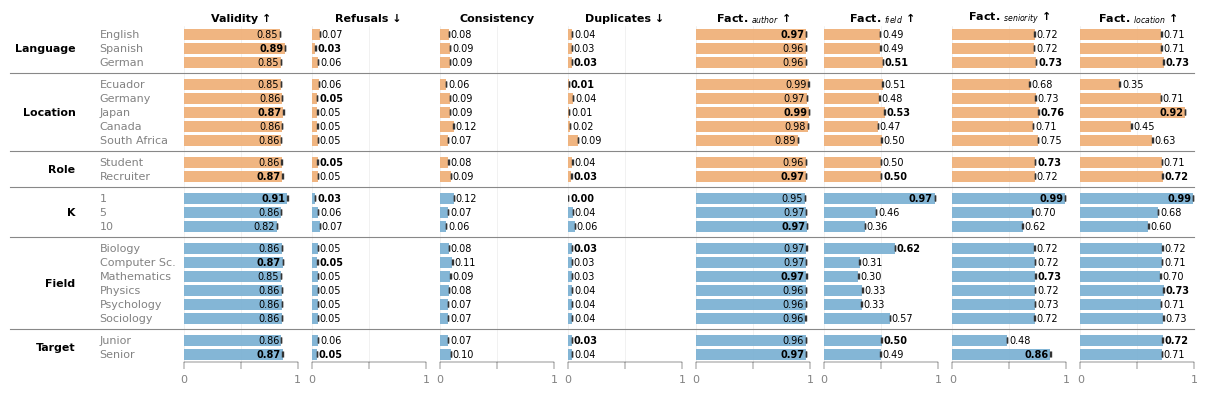

social
../../../results/plots/plot_social_stacked.pdf
Saved → ../../../results/plots/plot_social_stacked.pdf


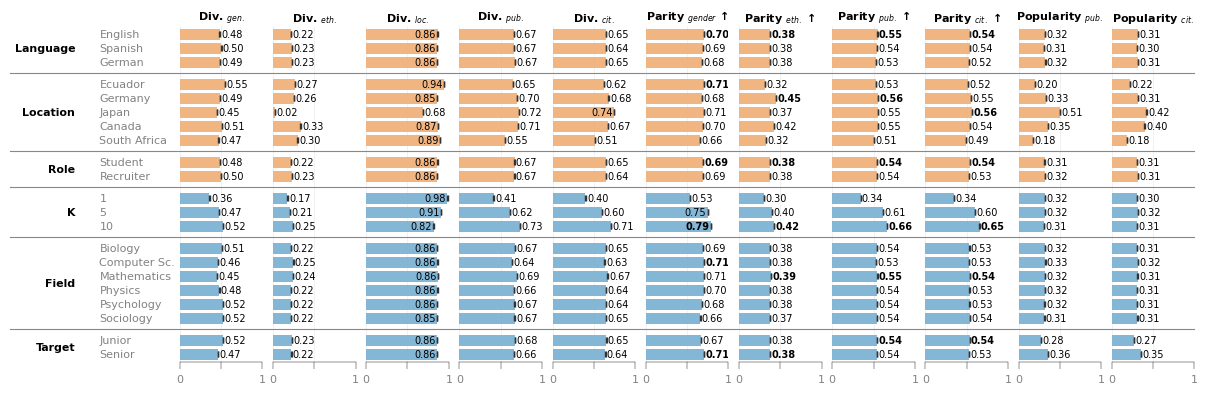

In [11]:
variables = {'persona': PERSONA_VARIABLES, 'context': MAIN_CONTEXT_VARIABLES}

df_metric = pd.DataFrame()
group_configs = []
for i, (prompt_var_class, vars) in enumerate(variables.items()):
    for j, var in enumerate(vars):
        tmp = aggregate_scores(df_valid_calls, [var]).rename(columns={var: 'label'})
        tmp.loc[:,'column'] = var
        df_metric = pd.concat([df_metric, tmp], ignore_index=True)

        group_configs.append({'label': var.split("_en")[0].capitalize(), 
                              'column': 'label', 
                              'color': PROMPT_VAR_COLORS.get(prompt_var_class), 
                              'filter': {'column':var},
                              'order': ORDER_MAP[var],
                              'shade': False})
            
for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_stacked.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_metric,
        group_configs=group_configs,
        row_labels = SENIORITY_MAP | ROLE_MAP | {'Computer Science':'Computer Sc.'},
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(group_configs)/1.1),
        textwrap_width = 20,
        section_style='plain',
        section_label_pad=0.2,
        section_label_align='right',
        row_label_align='left',
        section_label_width=0.5,
        row_label_width=1.9,
        row_label_pad=0.3,
        section_sep_left_pad=-0.22
    )



## RQ3: Insfrastructure

technical
../../../results/plots/plot_infrastructure_technical.pdf
Saved → ../../../results/plots/plot_infrastructure_technical.pdf


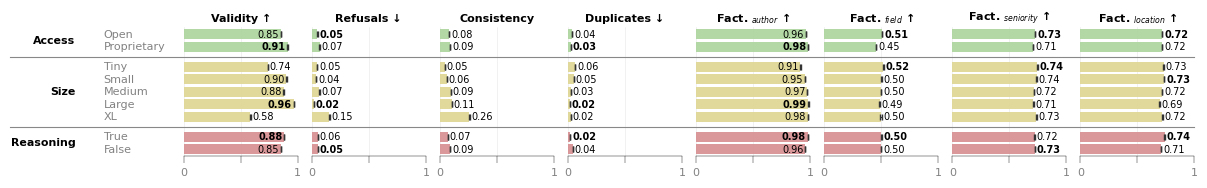

social
../../../results/plots/plot_infrastructure_social.pdf
Saved → ../../../results/plots/plot_infrastructure_social.pdf


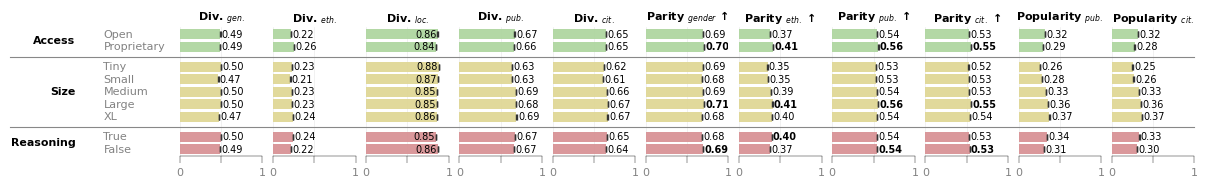

In [12]:

df_infra = pd.DataFrame()
for c in ['model_access','model_size','model_class']:
    tmp = aggregate_scores(df_valid_calls, [c]).rename(columns={c: 'label'})
    tmp.loc[:,'column'] = c
    df_infra = pd.concat([df_infra, tmp], ignore_index=True)
# display(df_infra)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_infrastructure_{metric_type}.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_infra,
        group_configs=[
            {'label': MODEL_ARCHITECTURE_MAP['model_access'], 'column': 'label', 'filter': {'column': 'model_access'}, 'color': "#ADD59E", 'order': ACCESS_ORDER, 'shade': False},
            {'label': MODEL_ARCHITECTURE_MAP['model_size'],   'column': 'label', 'filter': {'column': 'model_size'},   'color': "#DFD693", 'order': SIZE_ORDER, 'shade': False},
            {'label': MODEL_ARCHITECTURE_MAP['model_class'],  'column': 'label', 'filter': {'column': 'model_class'},  'color': "#D78F93", 'order': REASONING_ORDER, 'shade': False},
        ],
        row_labels=ACCESS_MAP | SIZE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * 2.1),
        textwrap_width = 20,
        section_style='plain',
        section_label_pad=0.2,
        section_label_align='right',
        row_label_align='left',
        section_label_width=0.5,
        row_label_width=1.9,
        row_label_pad=0.3,
        section_sep_left_pad=-0.22
    )



## RQ4: Socio-Technical Trade-off

Scatter — 43 models
Technical max: 6.401, Social max: 2.367


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


../../../results/plots/plot_technical_vs_social.pdf


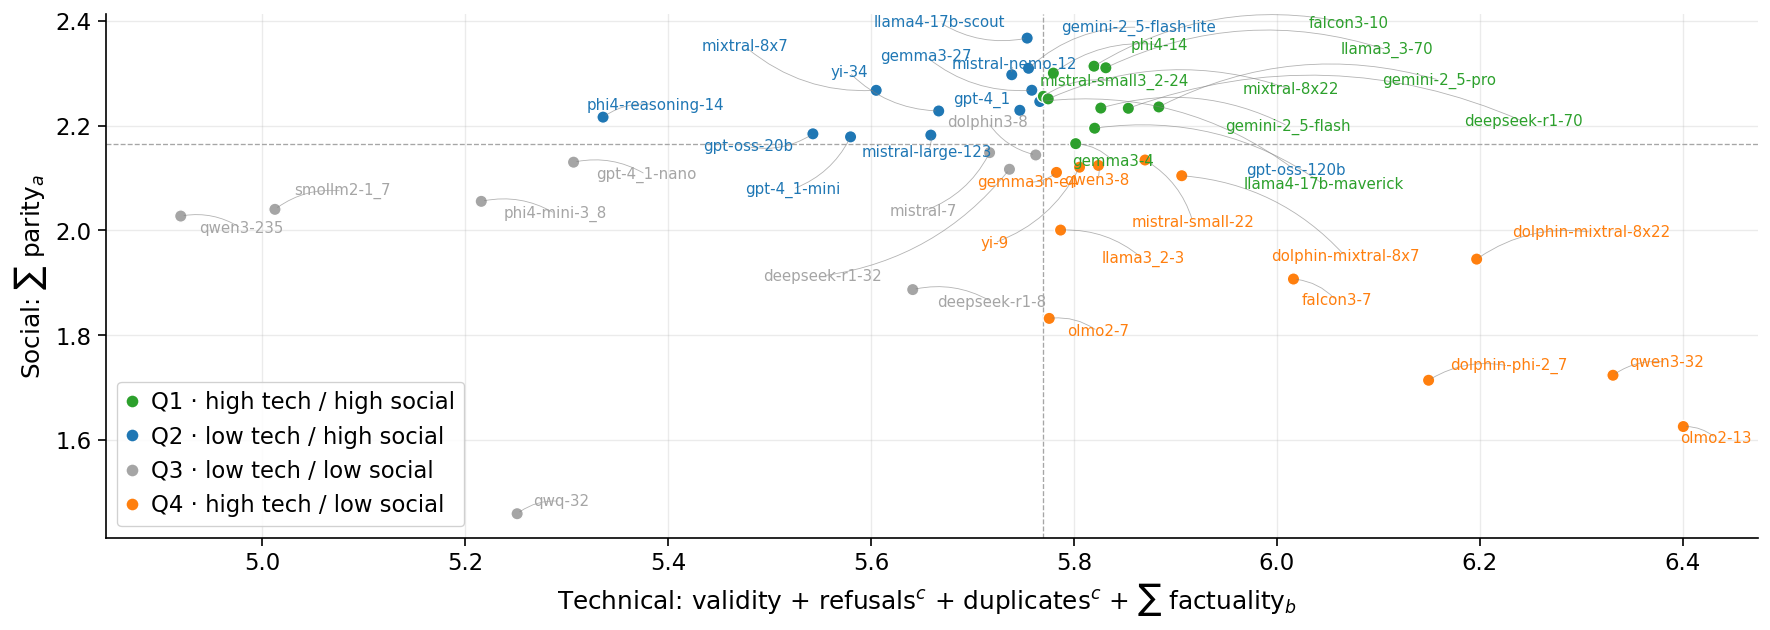

In [13]:
# ── Scatter: Social (∑ parity) vs Technical (∑ factuality + duplicates + factuality_location) ──

df_data_tmp = df_valid_calls.copy()

# Aggregate per model (mean over experimental cells, then over runs already inside per_cell)
agg_cols = TECHNICAL_METRICS_NORM + PARITY_METRICS

df_data_tmp.loc[:, 'color'] = df_data_tmp.loc[:,'model_family'].apply(lambda fam: MODEL_FAMILY_COLORS.get(fam, '#6B7280'))

per_model_mean = (df_data_tmp.groupby(['model_short_name','model_family', 'color'], dropna=False, observed=True)[agg_cols]
                  .mean()
                  .reset_index())
per_model_std = (df_data_tmp.groupby(['model_short_name','model_family', 'color'], dropna=False, observed=True)[agg_cols]
                  .std()
                  .reset_index())

per_model_mean['x_technical'] = per_model_mean[TECHNICAL_METRICS_NORM].sum(axis=1, skipna=False)
per_model_mean['y_social']    = per_model_mean[PARITY_METRICS].sum(axis=1, skipna=False)

per_model_std['x_technical'] = per_model_std[TECHNICAL_METRICS_NORM].sum(axis=1, skipna=False)
per_model_std['y_social']    = per_model_std[PARITY_METRICS].sum(axis=1, skipna=False)

print(f'Scatter — {per_model_mean.model_short_name.nunique()} models')
print(f"Technical max: {per_model_mean['x_technical'].max():.3f}, Social max: {per_model_mean['y_social'].max():.3f}")

fig, ax = plot_quadrant_scatter(per_model_mean, label_col="model_short_name", figsize=(FIG_WIDTH, 5.5), show_quadrant_legend=True)

fn = str(PLOTS_DIR / f'plot_technical_vs_social.pdf')
plt.savefig(fn, bbox_inches='tight', dpi=FIG_DPI)
print(fn)

plt.show()
plt.close()


# Additional

___


## K

,k,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_author_mean,factuality_author_ci,factuality_author_std,factuality_field_mean,factuality_field_ci,factuality_field_std,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,1,309600,0.9096,0.0010,0.2868,0.0311,0.0006,0.1735,0.1223,0.0008,0.2233,0.0031,0.0001,0.0401,0.9515,0.0008,0.2125,0.9681,0.0011,0.1287,...,0.0018,0.4648,0.3226,0.0018,0.4625,0.3488,0.0019,0.4717,0.3485,0.0019,0.4711,0.3027,0.0018,0.4550,0.3226,0.0018,0.4625,0.3027,0.0018,0.4550
1,5,309600,0.8560,0.0012,0.3511,0.0567,0.0008,0.2313,0.0735,0.0005,0.1286,0.0446,0.0005,0.1405,0.9653,0.0005,0.1415,0.4563,0.0015,0.2540,...,0.0011,0.2845,0.3221,0.0012,0.3065,0.3490,0.0013,0.3484,0.3329,0.0011,0.2882,0.3181,0.0012,0.3113,0.3221,0.0012,0.3065,0.3181,0.0012,0.3113
2,10,309600,0.8199,0.0014,0.3843,0.0702,0.0009,0.2555,0.0577,0.0004,0.1015,0.0607,0.0006,0.1545,0.9740,0.0005,0.1168,0.3554,0.0013,0.2457,...,0.0010,0.2448,0.3085,0.0011,0.2692,0.3565,0.0013,0.3192,0.3358,0.0010,0.2485,0.3077,0.0011,0.2751,0.3085,0.0011,0.2692,0.3077,0.0011,0.2751


technical
../../../results/plots/plot_technical_k.pdf
Saved → ../../../results/plots/plot_technical_k.pdf


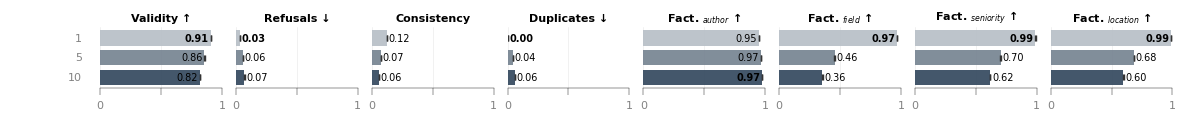

social
../../../results/plots/plot_social_k.pdf
Saved → ../../../results/plots/plot_social_k.pdf


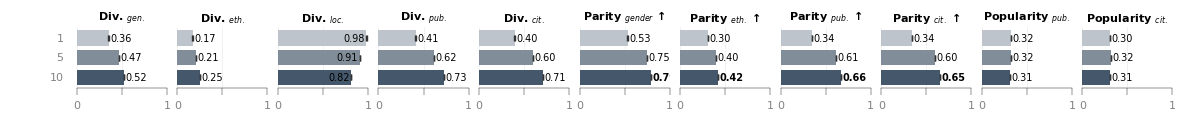

In [38]:
df_k = aggregate_scores(df_valid_calls, ['k'])
display(df_k)

for metric_type, metric_list in METRIC_TYPES.items():

    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_k.pdf')
    print(fn)
    plot_grouped_metrics(
        df_k,
        group_configs=[
            {'label': 'Top-k', 'column': 'k', 'color': '#34495E', 'order': K_ORDER},
        ],
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=FIG_SIZE
    )

### K and Language

technical
../../../results/plots/plot_technical_k_lang.pdf
Saved → ../../../results/plots/plot_technical_k_lang.pdf


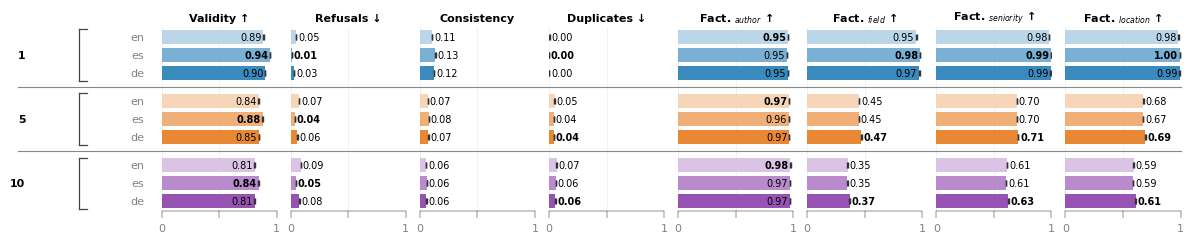

social
../../../results/plots/plot_social_k_lang.pdf
Saved → ../../../results/plots/plot_social_k_lang.pdf


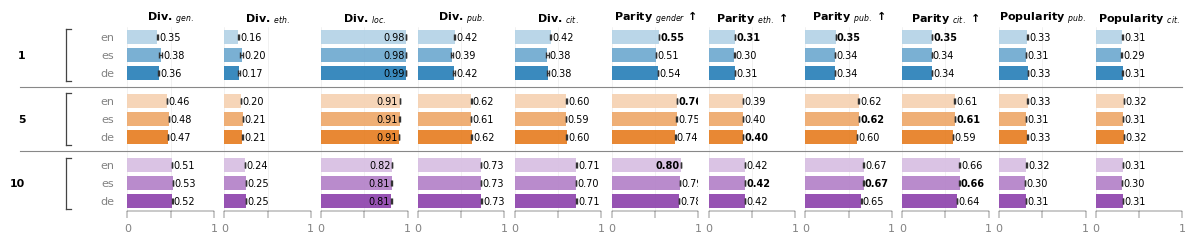

In [39]:

df_k_lang = aggregate_scores(df_valid_calls, ['k','language_en'])
# display(df_k_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_k_lang.pdf')
    print(fn)
    
    plot_grouped_metrics_labeled(
        df_k_lang,
        group_configs=[
            {'label': str(k), 
             'column': 'language_en', 'color': K_COLORS[k], 'filter': {'k': k}, 'order': LANGUAGE_ORDER} for k in K_ORDER
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(LANGUAGE_ORDER))
    )


## Language

,language_en,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_author_mean,factuality_author_ci,factuality_author_std,factuality_field_mean,factuality_field_ci,factuality_field_std,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,English,309600,0.8454,0.0013,0.3615,0.0701,0.0009,0.2553,0.0770,0.0006,0.1526,0.0390,0.0005,0.1284,0.9654,0.0006,0.1554,0.4910,0.0020,0.3152,...,0.0013,0.3374,0.3239,0.0014,0.3531,0.3506,0.0015,0.3805,0.3350,0.0014,0.3423,0.3144,0.0014,0.3525,0.3239,0.0014,0.3531,0.3144,0.0014,0.3525
1,German,309600,0.8517,0.0013,0.3554,0.0557,0.0008,0.2293,0.0857,0.0006,0.1622,0.0325,0.0005,0.1210,0.9636,0.0006,0.1665,0.5142,0.0022,0.3272,...,0.0014,0.3513,0.3243,0.0014,0.3638,0.3425,0.0015,0.3887,0.3435,0.0014,0.3583,0.3141,0.0014,0.3622,0.3243,0.0014,0.3638,0.3141,0.0014,0.3622
2,Spanish,309600,0.8884,0.0011,0.3148,0.0322,0.0006,0.1765,0.0915,0.0006,0.1723,0.0340,0.0005,0.1212,0.9608,0.0006,0.1696,0.4920,0.0020,0.3177,...,0.0013,0.3429,0.3058,0.0013,0.3488,0.3605,0.0015,0.3850,0.3385,0.0013,0.3454,0.3010,0.0013,0.3502,0.3058,0.0013,0.3488,0.3010,0.0013,0.3502


technical
../../../results/plots/plot_technical_lang.pdf
Saved → ../../../results/plots/plot_technical_lang.pdf


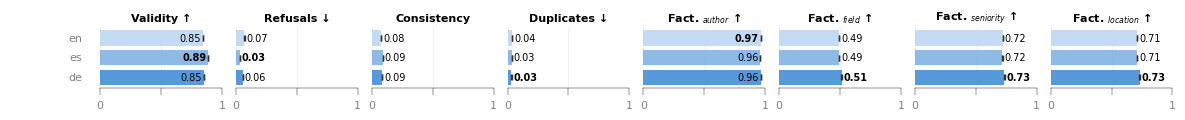

social
../../../results/plots/plot_social_lang.pdf
Saved → ../../../results/plots/plot_social_lang.pdf


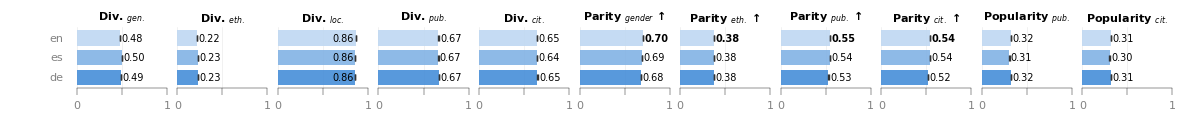

In [40]:

df_lang = aggregate_scores(df_valid_calls, ['language_en'])
display(df_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_lang,
        group_configs=[
            {'label': 'Language', 
             'column': 'language_en', 
             'color': '#4A90D9',
             'order': LANGUAGE_ORDER},
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=FIG_SIZE
    )


### Language and K

technical
../../../results/plots/plot_technical_lang_k.pdf
Saved → ../../../results/plots/plot_technical_lang_k.pdf


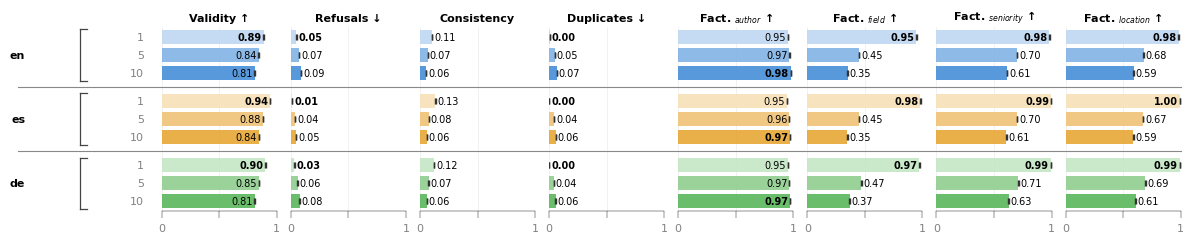

social
../../../results/plots/plot_social_lang_k.pdf
Saved → ../../../results/plots/plot_social_lang_k.pdf


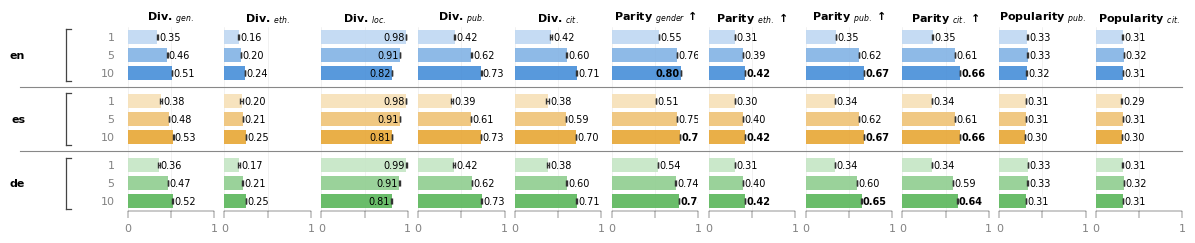

In [41]:
df_lang_k = aggregate_scores(df_valid_calls, ['language_en','k'])
# display(df_lang_k)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_lang_k.pdf')
    print(fn)
    
    plot_grouped_metrics_labeled(
        df_lang_k,
        group_configs=[
            {'label': LANGUAGE_MAP[lang], 
             'column': 'k', 
             'color': LANGUAGE_COLORS[lang],
             'filter': {'language_en': lang}, 
             'order': K_ORDER} for lang in LANGUAGE_ORDER
        ],
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(LANGUAGE_ORDER))
    )


### Language and Task

technical
../../../results/plots/plot_technical_task_lang.pdf
Saved → ../../../results/plots/plot_technical_task_lang.pdf


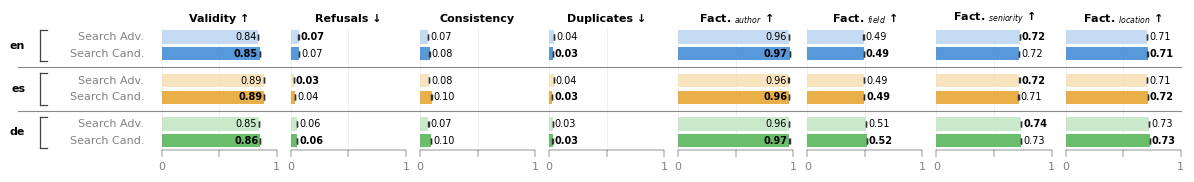

social
../../../results/plots/plot_social_task_lang.pdf
Saved → ../../../results/plots/plot_social_task_lang.pdf


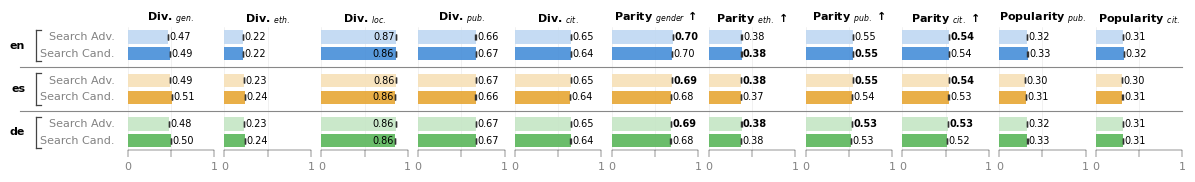

In [42]:

from pydoc import text


df_lang_task = aggregate_scores(df_valid_calls, ['language_en','task_en'])
# display(df_lang_task)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_task_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_lang_task,
        group_configs=[
            {'label': LANGUAGE_MAP[language], 
             'column': 'task_en', 
             'color': LANGUAGE_COLORS[language],
             'filter': {'language_en': language}, 
             'order': TASK_ORDER}
            for language in LANGUAGE_ORDER
        ],
        # section_labels=LANGUAGE_MAP,
        row_labels=TASK_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(TASK_ORDER)),
        textwrap_width=25
    )


## Location

,location_en,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_author_mean,factuality_author_ci,factuality_author_std,factuality_field_mean,factuality_field_ci,factuality_field_std,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,Canada,185760,0.8634,0.0016,0.3435,0.0503,0.0010,0.2186,0.1199,0.0009,0.1907,0.0196,0.0004,0.0882,0.9791,0.0006,0.1229,0.4700,0.0025,0.3139,...,0.0018,0.3509,0.3536,0.0018,0.3566,0.2598,0.0017,0.3395,0.3440,0.0017,0.3493,0.3962,0.0019,0.3751,0.3536,0.0018,0.3566,0.3962,0.0019,0.3751
1,Ecuador,185760,0.8522,0.0016,0.3549,0.0608,0.0011,0.2390,0.0570,0.0006,0.1317,0.0105,0.0003,0.0707,0.9854,0.0005,0.1085,0.5126,0.0028,0.3194,...,0.0018,0.3584,0.2029,0.0015,0.2934,0.4126,0.0021,0.4115,0.3682,0.0018,0.3565,0.2192,0.0015,0.3070,0.2029,0.0015,0.2934,0.2192,0.0015,0.3070
2,Germany,185760,0.8638,0.0016,0.3431,0.0486,0.0010,0.2150,0.0883,0.0008,0.1641,0.0449,0.0007,0.1351,0.9695,0.0007,0.1522,0.4845,0.0025,0.3159,...,0.0017,0.3366,0.3311,0.0018,0.3516,0.3295,0.0019,0.3668,0.3573,0.0018,0.3511,0.3132,0.0018,0.3489,0.3311,0.0018,0.3516,0.3132,0.0018,0.3489
3,Japan,185760,0.8739,0.0015,0.3320,0.0496,0.0010,0.2172,0.0857,0.0008,0.1645,0.0106,0.0004,0.0746,0.9888,0.0005,0.0955,0.5306,0.0028,0.3315,...,0.0016,0.3152,0.5051,0.0018,0.3666,0.2381,0.0016,0.3164,0.3419,0.0017,0.3401,0.4200,0.0018,0.3638,0.5051,0.0018,0.3666,0.4200,0.0018,0.3638
4,South Africa,185760,0.8559,0.0016,0.3512,0.0539,0.0010,0.2259,0.0729,0.0007,0.1502,0.0905,0.0009,0.1879,0.8927,0.0013,0.2636,0.5039,0.0028,0.3171,...,0.0018,0.3435,0.1778,0.0016,0.2952,0.5371,0.0021,0.4085,0.2783,0.0018,0.3388,0.1845,0.0016,0.3086,0.1778,0.0016,0.2952,0.1845,0.0016,0.3086


technical
../../../results/plots/plot_technical_loc.pdf
Saved → ../../../results/plots/plot_technical_loc.pdf


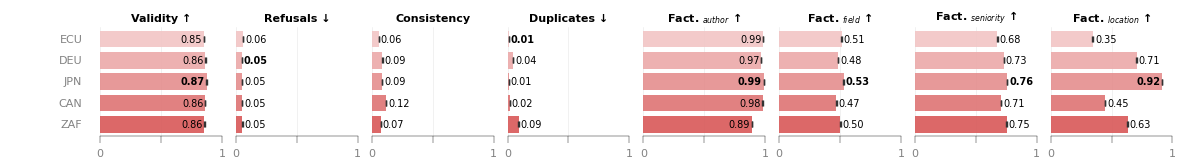

social
../../../results/plots/plot_social_loc.pdf
Saved → ../../../results/plots/plot_social_loc.pdf


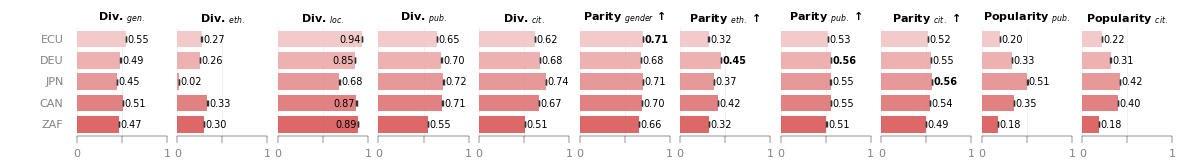

In [43]:

df_loc = aggregate_scores(df_valid_calls, ['location_en'])
display(df_loc)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_loc.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_loc,
        group_configs=[
            {'label': 'Location', 
             'column': 'location_en', 
             'color': '#D95B5B',
             'order': LOCATION_ORDER},
        ],
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        row_labels=LOCATION_MAP,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT + (len(LOCATION_ORDER)/8))
    )


### Location and Language

technical
../../../results/plots/plot_technical_loc_lang.pdf
Saved → ../../../results/plots/plot_technical_loc_lang.pdf


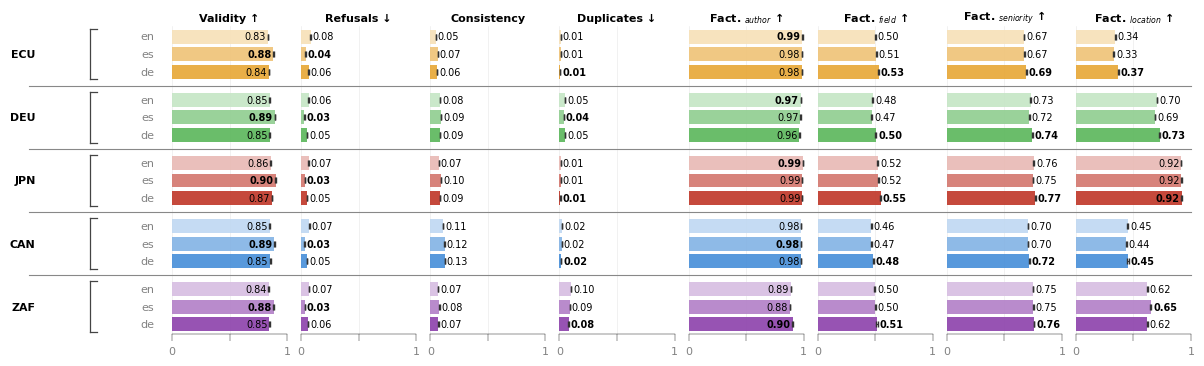

social
../../../results/plots/plot_social_loc_lang.pdf
Saved → ../../../results/plots/plot_social_loc_lang.pdf


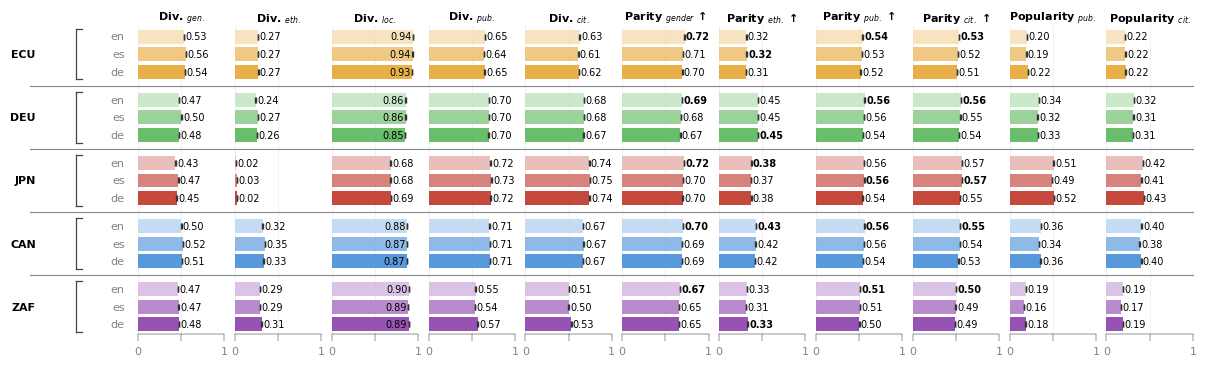

In [44]:

df_loc_lang = aggregate_scores(df_valid_calls, ['location_en','language_en'])
# display(df_loc_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_loc_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_loc_lang,
        group_configs=[
            {'label': LOCATION_MAP[loc], 
             'column': 
             'language_en', 
             'color': LOCATION_COLORS[loc],
             'filter': {'location_en': loc}, 
             'order': LANGUAGE_ORDER} for loc in LOCATION_ORDER
        ],
        # section_labels=LOCATION_MAP,
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(LOCATION_ORDER))   
    );


## Task

,task_en,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_author_mean,factuality_author_ci,factuality_author_std,factuality_field_mean,factuality_field_ci,factuality_field_std,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,seeking an advisor,464400,0.8577,0.0010,0.3494,0.0504,0.0006,0.2188,0.0756,0.0005,0.1533,0.0395,0.0004,0.1308,0.9603,0.0005,0.1709,0.4973,0.0017,0.3197,...,0.0011,0.3423,0.3146,0.0011,0.3536,0.3609,0.0012,0.3850,0.3329,0.0011,0.3457,0.3061,0.0011,0.3529,0.3146,0.0011,0.3536,0.3061,0.0011,0.3529
1,seeking potential hires,464400,0.8660,0.0010,0.3407,0.0549,0.0007,0.2278,0.0940,0.0005,0.1713,0.0308,0.0004,0.1158,0.9661,0.0005,0.1571,0.5003,0.0017,0.3206,...,0.0011,0.3454,0.3209,0.0011,0.3568,0.3421,0.0012,0.3844,0.3449,0.0011,0.3514,0.3130,0.0011,0.3569,0.3209,0.0011,0.3568,0.3130,0.0011,0.3569


technical
../../../results/plots/plot_technical_task.pdf
Saved → ../../../results/plots/plot_technical_task.pdf


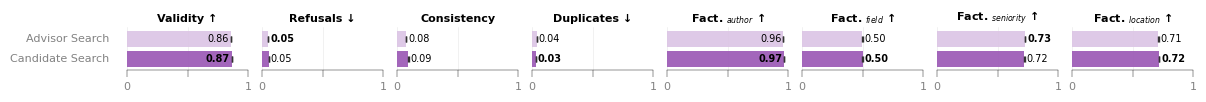

social
../../../results/plots/plot_social_task.pdf
Saved → ../../../results/plots/plot_social_task.pdf


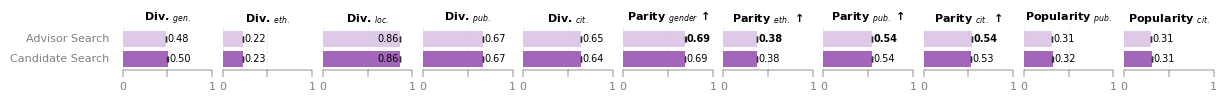

In [45]:
df_task = aggregate_scores(df_valid_calls, ['task_en'])
display(df_task)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_task.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_task,
        group_configs=[
            {'label': 'Task', 
             'column': 'task_en', 
             'color': '#9B59B6',
             'order': TASK_ORDER},
        ],
        row_labels=TASK_MAP_LONG,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * 0.7),
        textwrap_width=20
    )


### Task and K

technical
../../../results/plots/plot_technical_task_k.pdf
Saved → ../../../results/plots/plot_technical_task_k.pdf


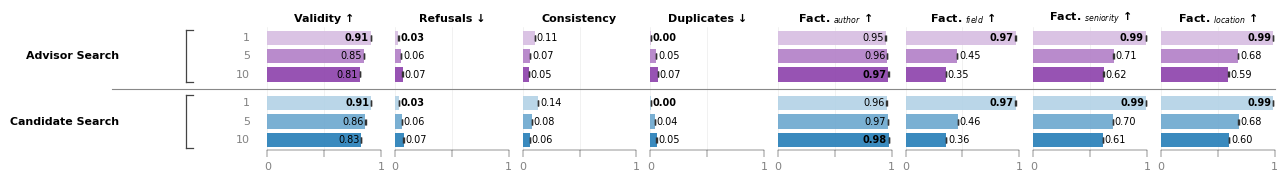

social
../../../results/plots/plot_social_task_k.pdf
Saved → ../../../results/plots/plot_social_task_k.pdf


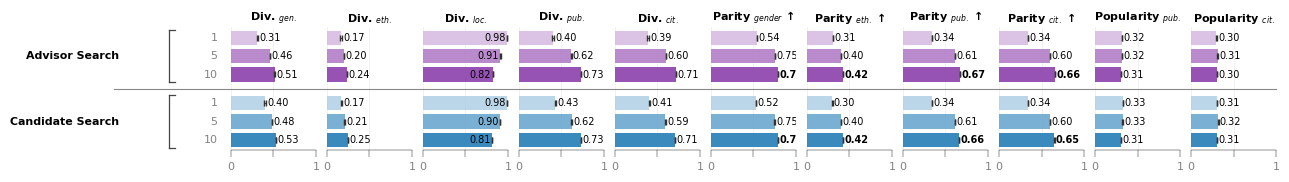

In [46]:

df_task_k = aggregate_scores(df_valid_calls, ['task_en','k'])
# display(df_task_k)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_task_k.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_task_k,
        group_configs=[
            {'label': TASK_MAP_LONG[task_val], 
             'column': 'k', 
             'color': TASK_COLORS[task_val],
             'filter': {'task_en': task_val}, 
             'order': K_ORDER} for task_val in TASK_ORDER
        ],
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(TASK_ORDER)),
        textwrap_width=20
    )


## Role

,role_en,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_author_mean,factuality_author_ci,factuality_author_std,factuality_field_mean,factuality_field_ci,factuality_field_std,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,Director/Recruiter,464400,0.8660,0.0010,0.3407,0.0549,0.0007,0.2278,0.0940,0.0005,0.1713,0.0308,0.0004,0.1158,0.9661,0.0005,0.1571,0.5003,0.0017,0.3206,...,0.0011,0.3454,0.3209,0.0011,0.3568,0.3421,0.0012,0.3844,0.3449,0.0011,0.3514,0.3130,0.0011,0.3569,0.3209,0.0011,0.3568,0.3130,0.0011,0.3569
1,PhD student,464400,0.8577,0.0010,0.3494,0.0504,0.0006,0.2188,0.0756,0.0005,0.1533,0.0395,0.0004,0.1308,0.9603,0.0005,0.1709,0.4973,0.0017,0.3197,...,0.0011,0.3423,0.3146,0.0011,0.3536,0.3609,0.0012,0.3850,0.3329,0.0011,0.3457,0.3061,0.0011,0.3529,0.3146,0.0011,0.3536,0.3061,0.0011,0.3529


technical
../../../results/plots/plot_technical_role.pdf
Saved → ../../../results/plots/plot_technical_role.pdf


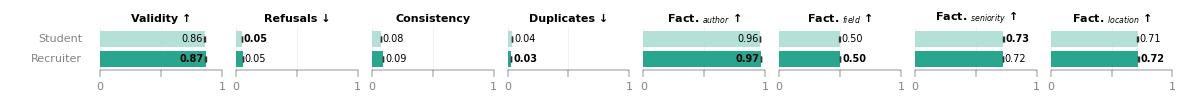

social
../../../results/plots/plot_social_role.pdf
Saved → ../../../results/plots/plot_social_role.pdf


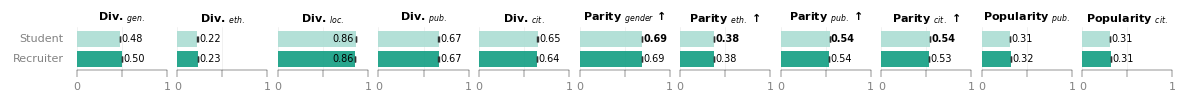

In [47]:

df_role = aggregate_scores(df_valid_calls, ['role_en'])
display(df_role)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_role.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_role,
        group_configs=[
            {'label': 'Role', 
             'column': 'role_en', 
             'color': '#16A085',
             'order': ROLE_ORDER},
        ],
        row_labels=ROLE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * 0.7)
    )

### Role and Language

technical
../../../results/plots/plot_technical_role_lang.pdf
Saved → ../../../results/plots/plot_technical_role_lang.pdf


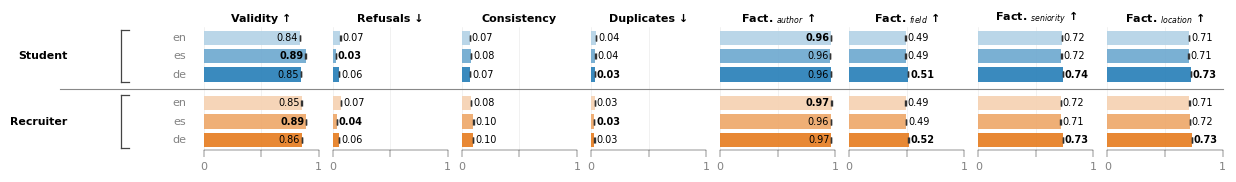

social
../../../results/plots/plot_social_role_lang.pdf
Saved → ../../../results/plots/plot_social_role_lang.pdf


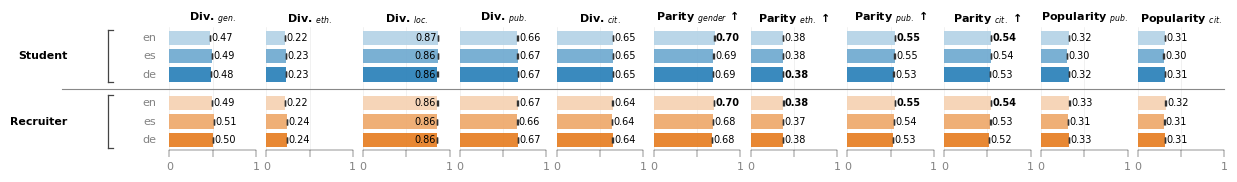

In [48]:

df_role_lang = aggregate_scores(df_valid_calls, ['role_en', 'language_en'])
# display(df_role_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_role_lang.pdf')
    print(fn)
        
    plot_grouped_metrics_labeled(
        df_role_lang,
        group_configs=[
            {'label': ROLE_MAP[role_val], 
             'column': 'language_en', 
             'color': ROLE_COLORS[role_val],
             'filter': {'role_en': role_val}, 
             'order': LANGUAGE_ORDER}
            for role_val in ROLE_ORDER
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(ROLE_ORDER))
    )

## Field

technical
../../../results/plots/plot_technical_field.pdf
Saved → ../../../results/plots/plot_technical_field.pdf


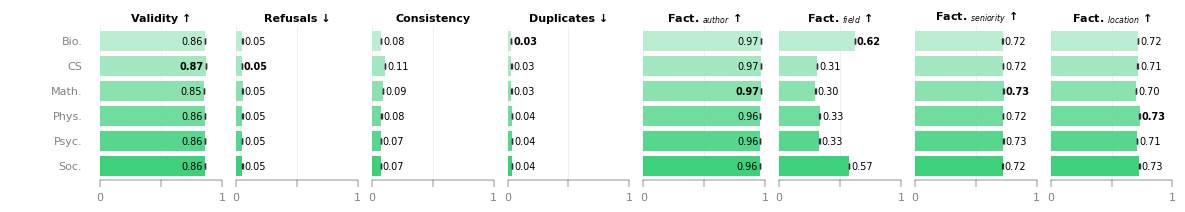

social
../../../results/plots/plot_social_field.pdf
Saved → ../../../results/plots/plot_social_field.pdf


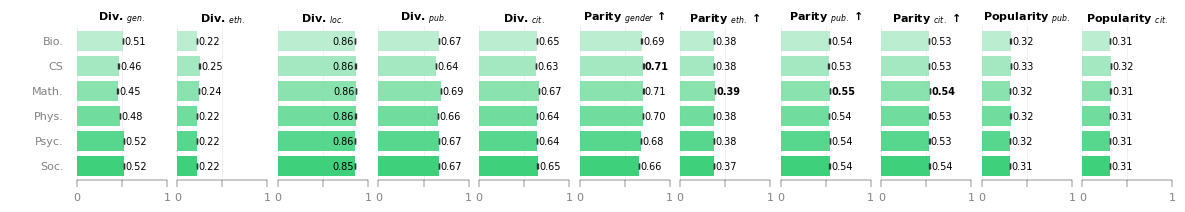

In [49]:

df_field = aggregate_scores(df_valid_calls, ['field_en'])
# display(df_field)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_field.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_field,
        group_configs=[
            {'label': 'Field', 
             'column': 'field_en', 
             'color': '#2ECC71', 
             'order': FIELD_ORDER},
        ],
        row_labels=FIELD_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT + (len(FIELD_ORDER)/5))
    )


### Field and Language

technical
../../../results/plots/plot_technical_field_lang.pdf
Saved → ../../../results/plots/plot_technical_field_lang.pdf


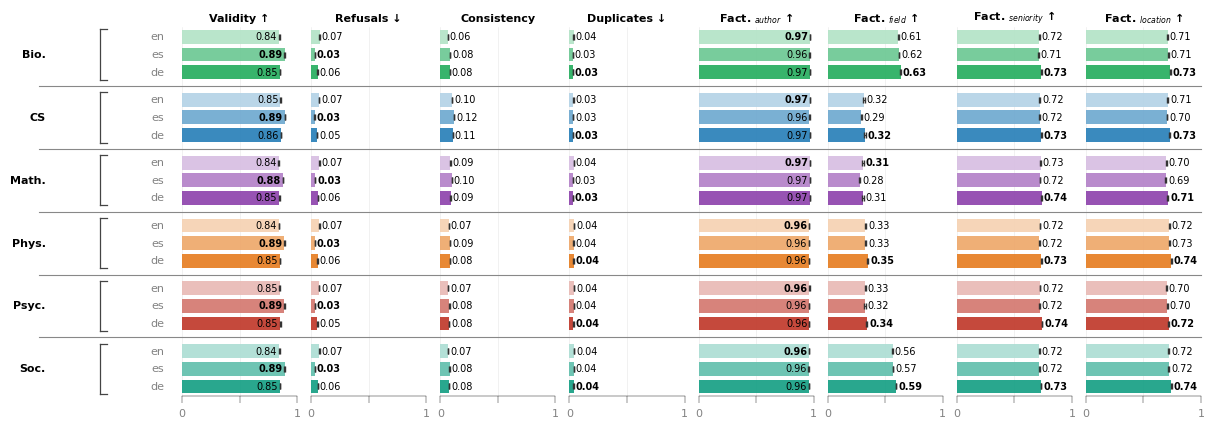

social
../../../results/plots/plot_social_field_lang.pdf
Saved → ../../../results/plots/plot_social_field_lang.pdf


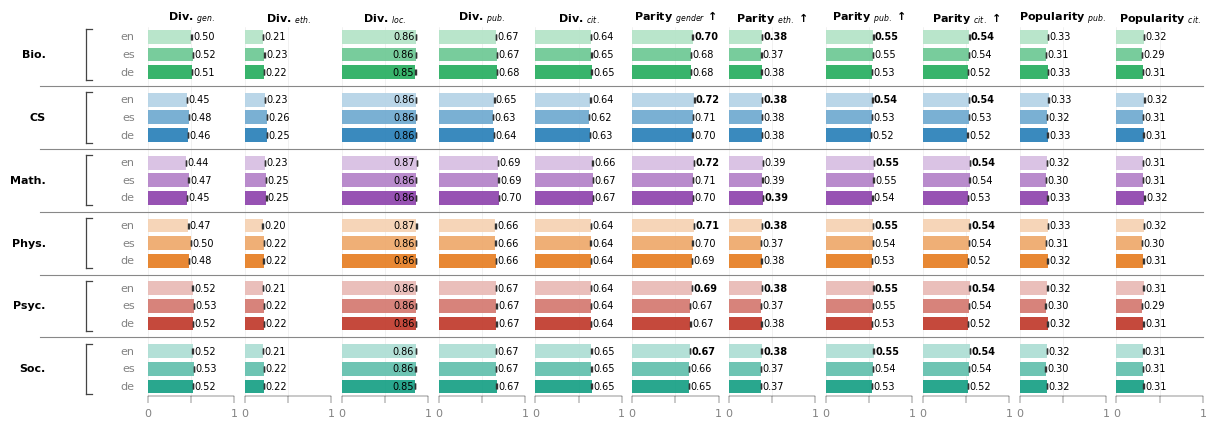

In [50]:

df_field_lang = aggregate_scores(df_valid_calls, ['field_en', 'language_en'])
# display(df_field_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_field_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_field_lang,
        group_configs=[
            {'label': FIELD_MAP[field_en], 
             'column': 'language_en', 
             'color': FIELD_COLORS[field_en], 
             'filter': {'field_en': field_en}, 
             'order': LANGUAGE_ORDER } for field_en in FIELD_ORDER
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(FIELD_ORDER))
    )




### Field and K

technical
../../../results/plots/plot_technical_field_k.pdf
Saved → ../../../results/plots/plot_technical_field_k.pdf


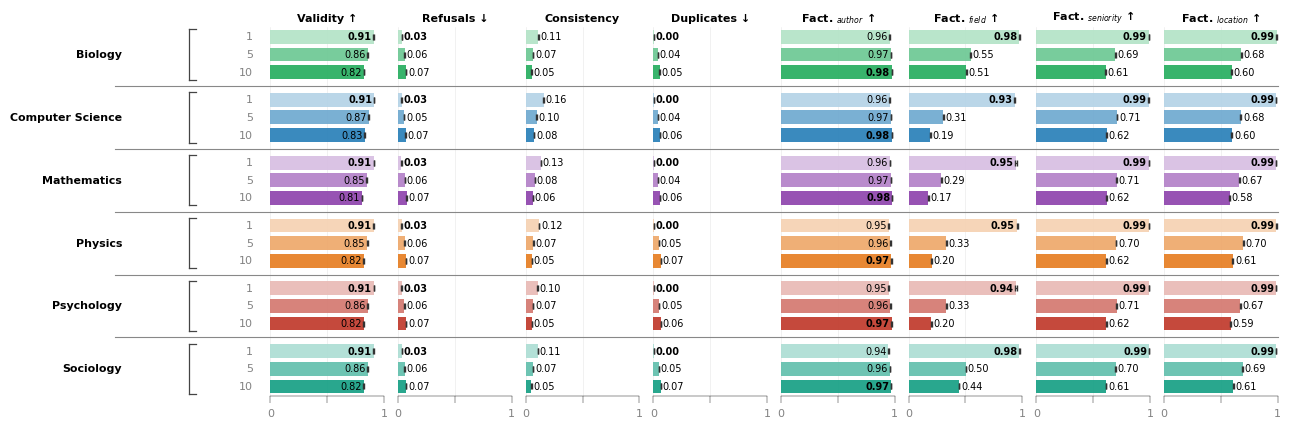

social
../../../results/plots/plot_social_field_k.pdf
Saved → ../../../results/plots/plot_social_field_k.pdf


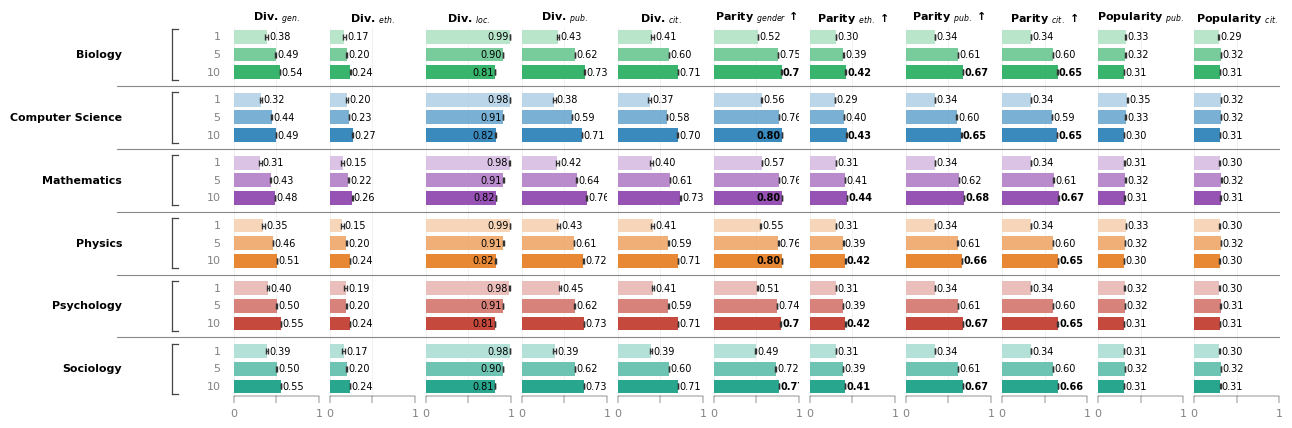

In [51]:

df_field_k = aggregate_scores(df_valid_calls, ['field_en', 'k'])
# display(df_field_k)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_field_k.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_field_k,
        group_configs=[
            {'label': field_en, 
             'column': 'k', 
             'color': FIELD_COLORS[field_en], 
             'filter': {'field_en': field_en}, 
             'order': K_ORDER } for field_en in FIELD_ORDER
        ],
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(FIELD_ORDER)),
        textwrap_width=20
    )




## Subfield

technical
../../../results/plots/plot_technical_subfield.pdf
Saved → ../../../results/plots/plot_technical_subfield.pdf


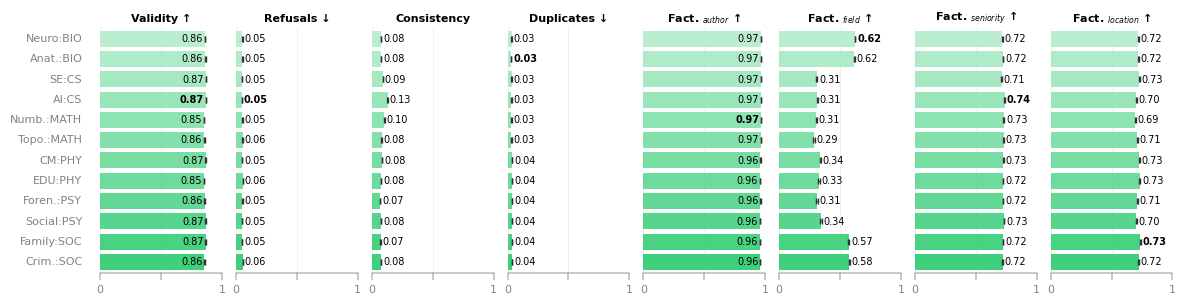

social
../../../results/plots/plot_social_subfield.pdf
Saved → ../../../results/plots/plot_social_subfield.pdf


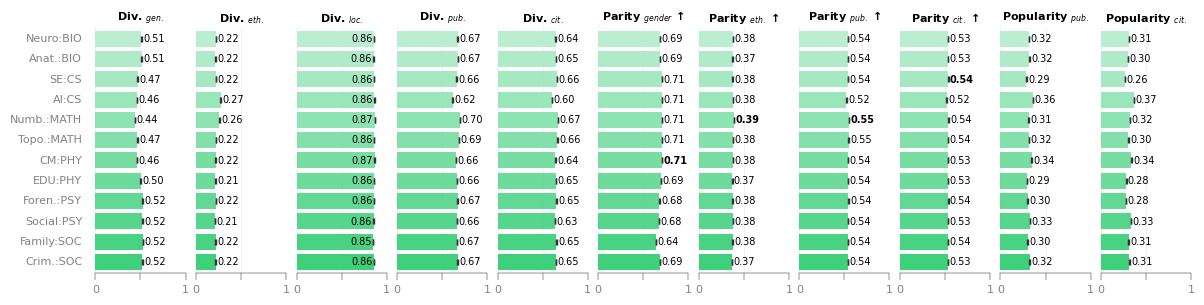

In [52]:

df_subfield = aggregate_scores(df_valid_calls, ['subfield_en'])
# display(df_subfield)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_subfield.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_subfield,
        group_configs=[
            {'label': 'Subfield', 
             'column': 'subfield_en', 
             'color': '#2ECC71', 
             'order': SUBFIELD_ORDER},
        ],
        row_labels=SUBFIELD_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT + (len(SUBFIELD_ORDER)/5))
    )


### Subfield and Language

technical
../../../results/plots/plot_technical_subfield_lang.pdf
Saved → ../../../results/plots/plot_technical_subfield_lang.pdf


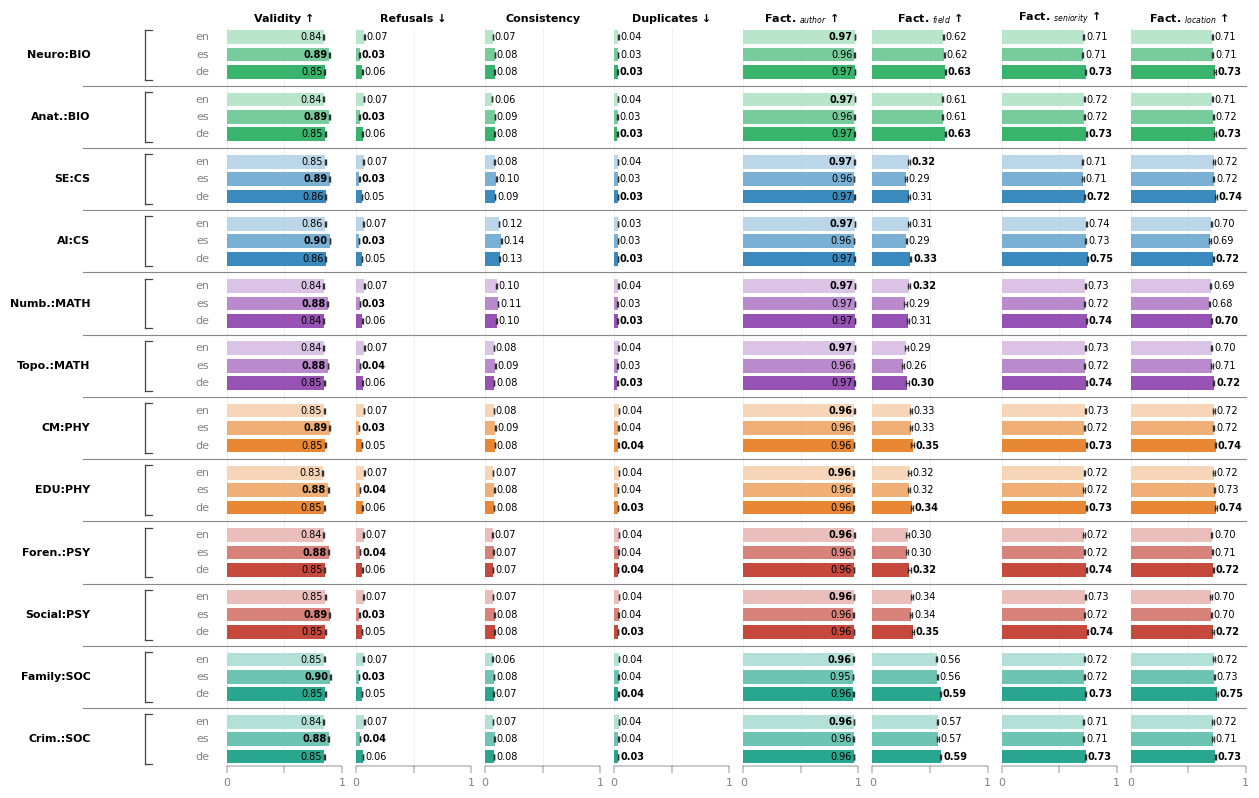

social
../../../results/plots/plot_social_subfield_lang.pdf
Saved → ../../../results/plots/plot_social_subfield_lang.pdf


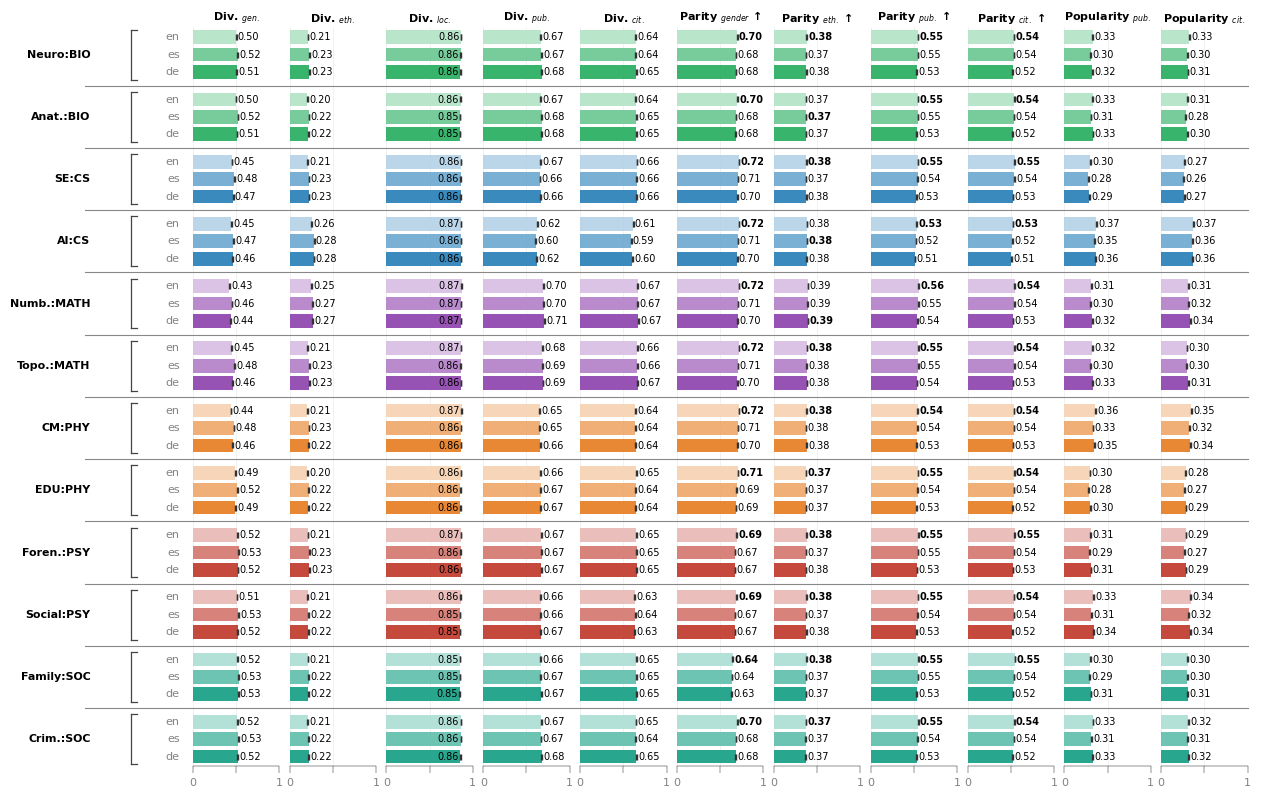

In [53]:

df_subfield_lang = aggregate_scores(df_valid_calls, ['subfield_en', 'language_en'])
# display(df_field_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_subfield_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_subfield_lang,
        group_configs=[
            {'label': SUBFIELD_MAP[subfield_en], 
             'column': 'language_en', 
             'color': SUBFIELD_COLORS[subfield_en], 
             'filter': {'subfield_en': subfield_en}, 
             'order': LANGUAGE_ORDER } for subfield_en in SUBFIELD_ORDER
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(SUBFIELD_ORDER))
    )




## Target (seniority)

,target_en,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_author_mean,factuality_author_ci,factuality_author_std,factuality_field_mean,factuality_field_ci,factuality_field_std,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,Junior Professor,464400,0.8565,0.0010,0.3506,0.0575,0.0007,0.2328,0.0726,0.0004,0.1462,0.0323,0.0004,0.1185,0.9611,0.0005,0.1676,0.5034,0.0017,0.3205,...,0.0011,0.3477,0.2756,0.0011,0.3351,0.3680,0.0012,0.3896,0.3629,0.0011,0.3536,0.2691,0.0011,0.3333,0.2756,0.0011,0.3351,0.2691,0.0011,0.3333
1,Senior Professor,464400,0.8672,0.0010,0.3394,0.0478,0.0006,0.2133,0.0970,0.0005,0.1769,0.0379,0.0004,0.1283,0.9653,0.0005,0.1605,0.4947,0.0016,0.3198,...,0.0011,0.3389,0.3600,0.0012,0.3695,0.3348,0.0012,0.3793,0.3150,0.0011,0.3419,0.3502,0.0012,0.3709,0.3600,0.0012,0.3695,0.3502,0.0012,0.3709


technical
../../../results/plots/plot_technical_seniority.pdf
Saved → ../../../results/plots/plot_technical_seniority.pdf


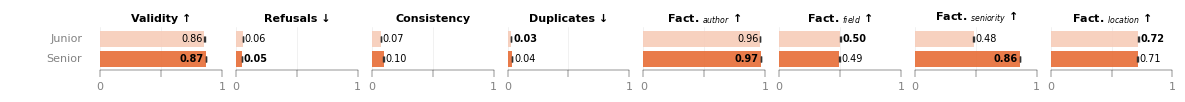

social
../../../results/plots/plot_social_seniority.pdf
Saved → ../../../results/plots/plot_social_seniority.pdf


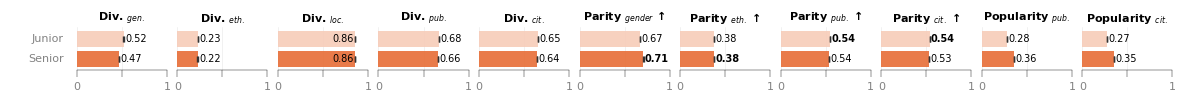

In [54]:

df_target = aggregate_scores(df_valid_calls, ['target_en'])
display(df_target)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_seniority.pdf')
    print(fn)
        
    plot_grouped_metrics_labeled(
        df_target,
        group_configs=[
            {'label': 'Target', 
             'column': 'target_en', 
             'color': '#E8703A',
             'order': SENIORITY_ORDER},
        ],
        row_labels=SENIORITY_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * 0.7)
    )

### Seniority and Language

technical
../../../results/plots/plot_technical_seniority_lang.pdf
Saved → ../../../results/plots/plot_technical_seniority_lang.pdf


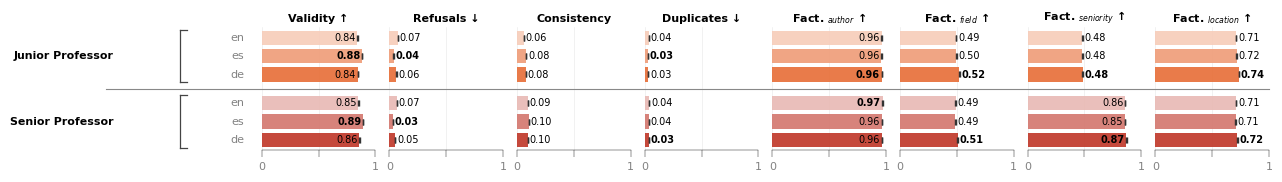

social
../../../results/plots/plot_social_seniority_lang.pdf
Saved → ../../../results/plots/plot_social_seniority_lang.pdf


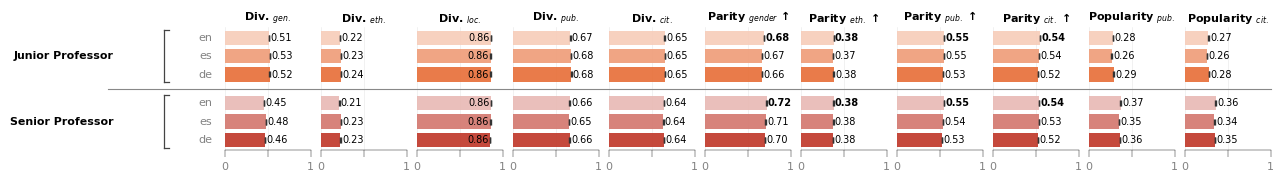

In [55]:

df_target_lang = aggregate_scores(df_valid_calls, ['target_en', 'language_en'])
# display(df_target_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_seniority_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_target_lang,
        group_configs=[
            {'label': target_en, 
             'column': 'language_en', 
             'color': SENIORITY_COLORS[target_en],
            'filter': {'target_en': target_en}, 
            'order': LANGUAGE_ORDER}
            for target_en in SENIORITY_ORDER
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(SENIORITY_ORDER)),
        textwrap_width=20
    )

## Model

technical
../../../results/plots/plot_technical_model.pdf
Saved → ../../../results/plots/plot_technical_model.pdf


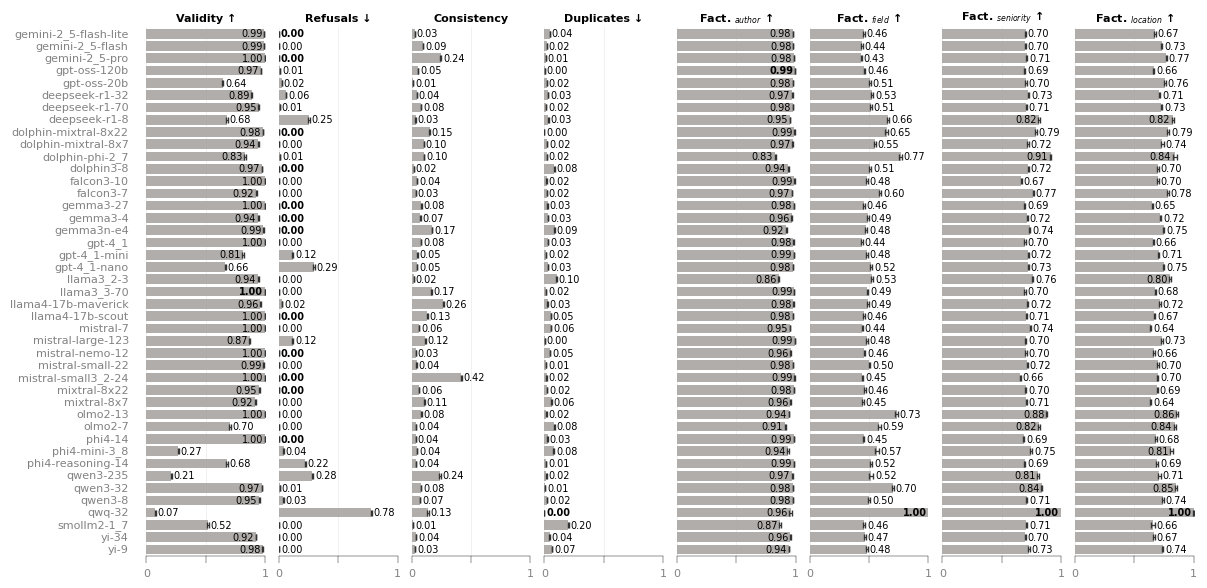

social
../../../results/plots/plot_social_model.pdf
Saved → ../../../results/plots/plot_social_model.pdf


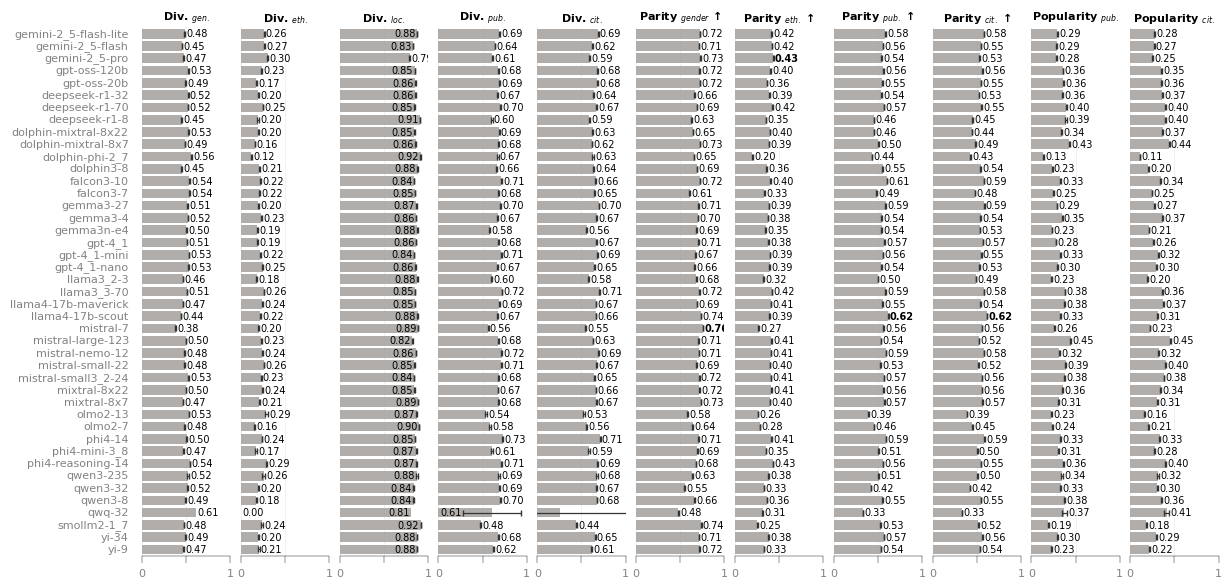

In [56]:

df_model = aggregate_scores(df_valid_calls, ['model_short_name'])
# display(df_model)
# model_order = df_model.sort_values('validity_mean', ascending=False)['model_short_name'].tolist()

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_model.pdf')
    print(fn)
        
    plot_grouped_metrics_labeled(
        df_model,
        group_configs=[
            {'label': 'Model', 
             'column': 'model_short_name', 
             'color': "#ABA6A3",'order': MODELS,
             'shade': False}
        ],
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * (len(MODELS)/5)),
        textwrap_width = 25,
    )

### Model and Language

technical
../../../results/plots/plot_technical_model_lang.pdf
Saved → ../../../results/plots/plot_technical_model_lang.pdf


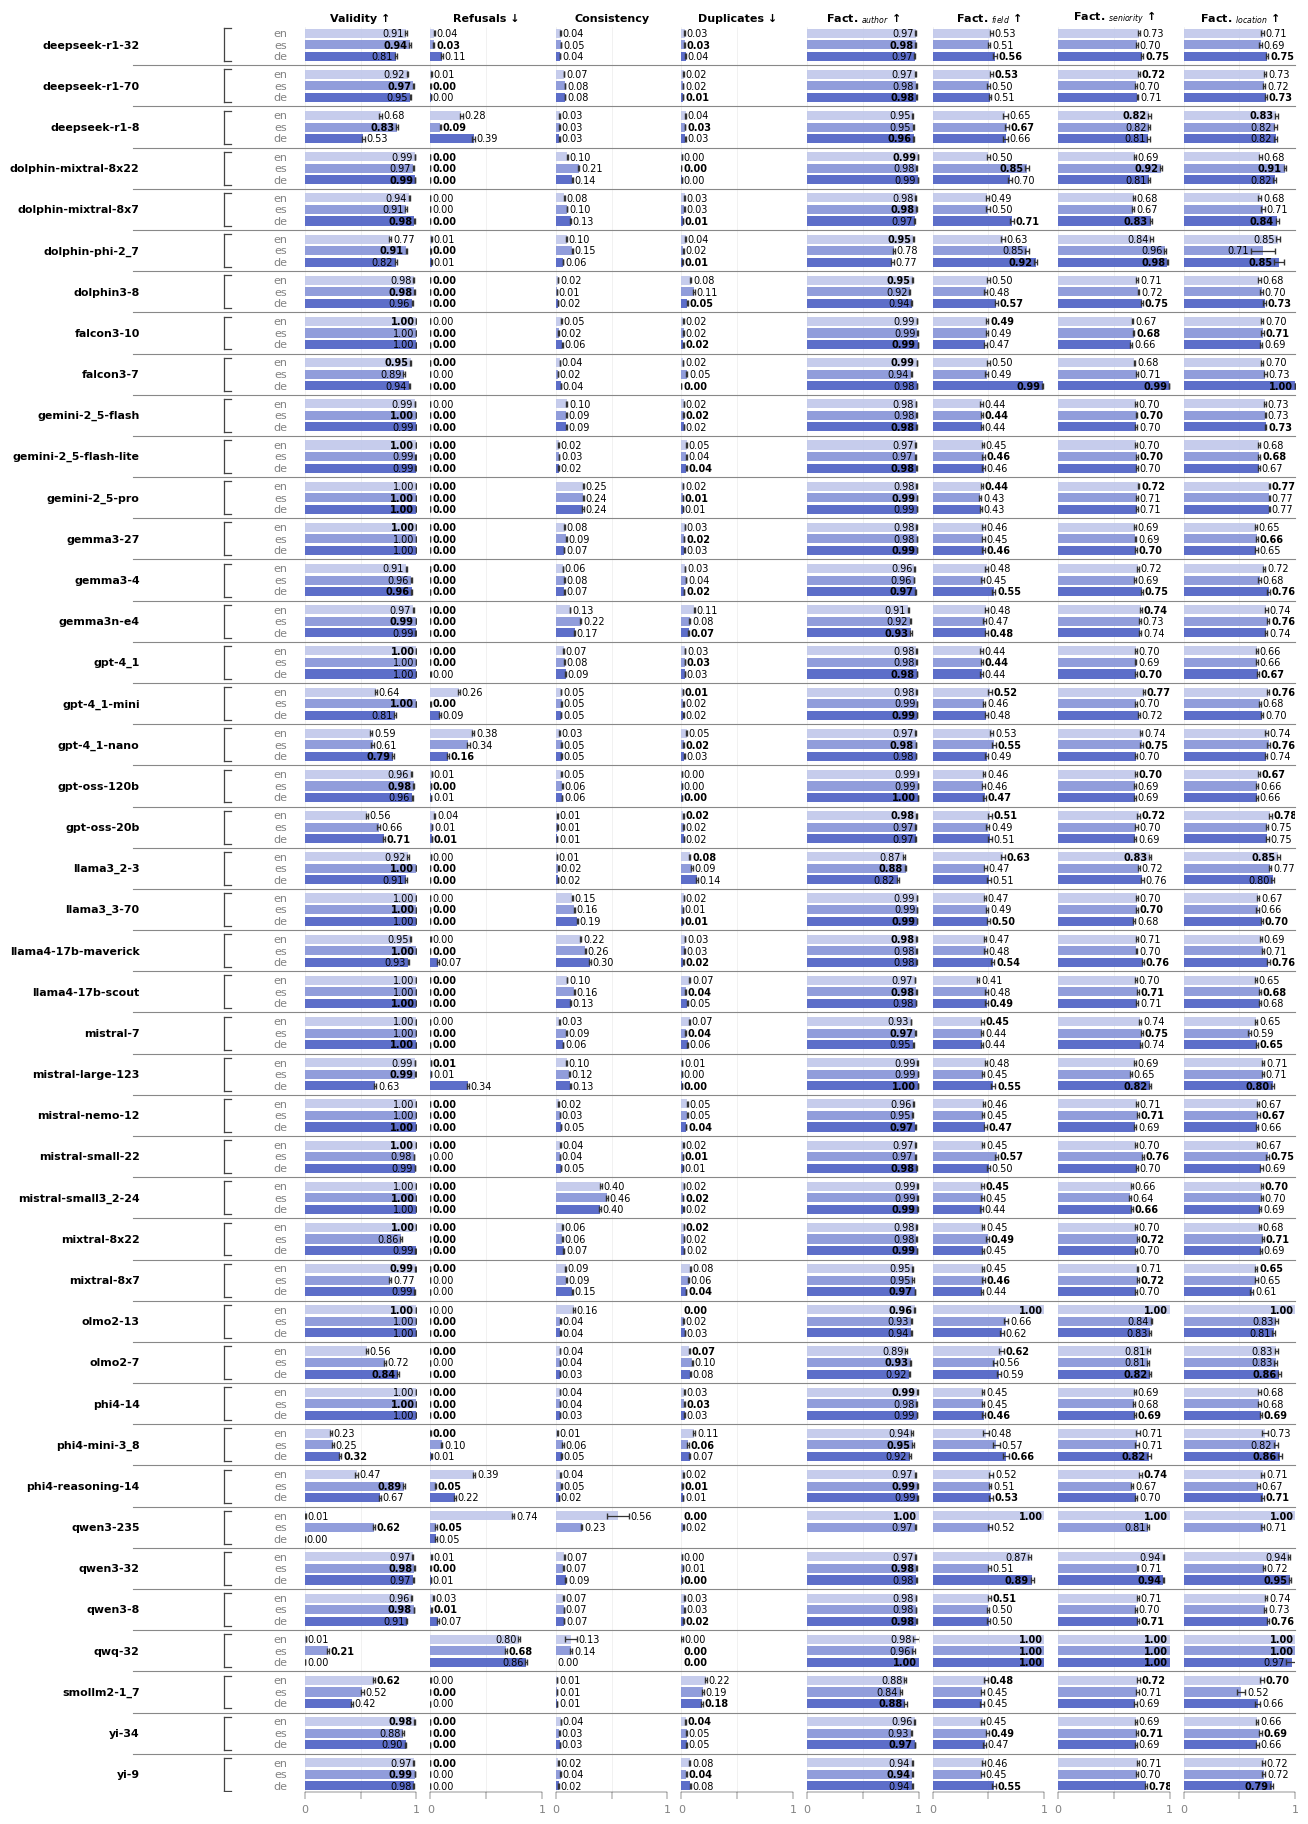

social
../../../results/plots/plot_social_model_lang.pdf
Saved → ../../../results/plots/plot_social_model_lang.pdf


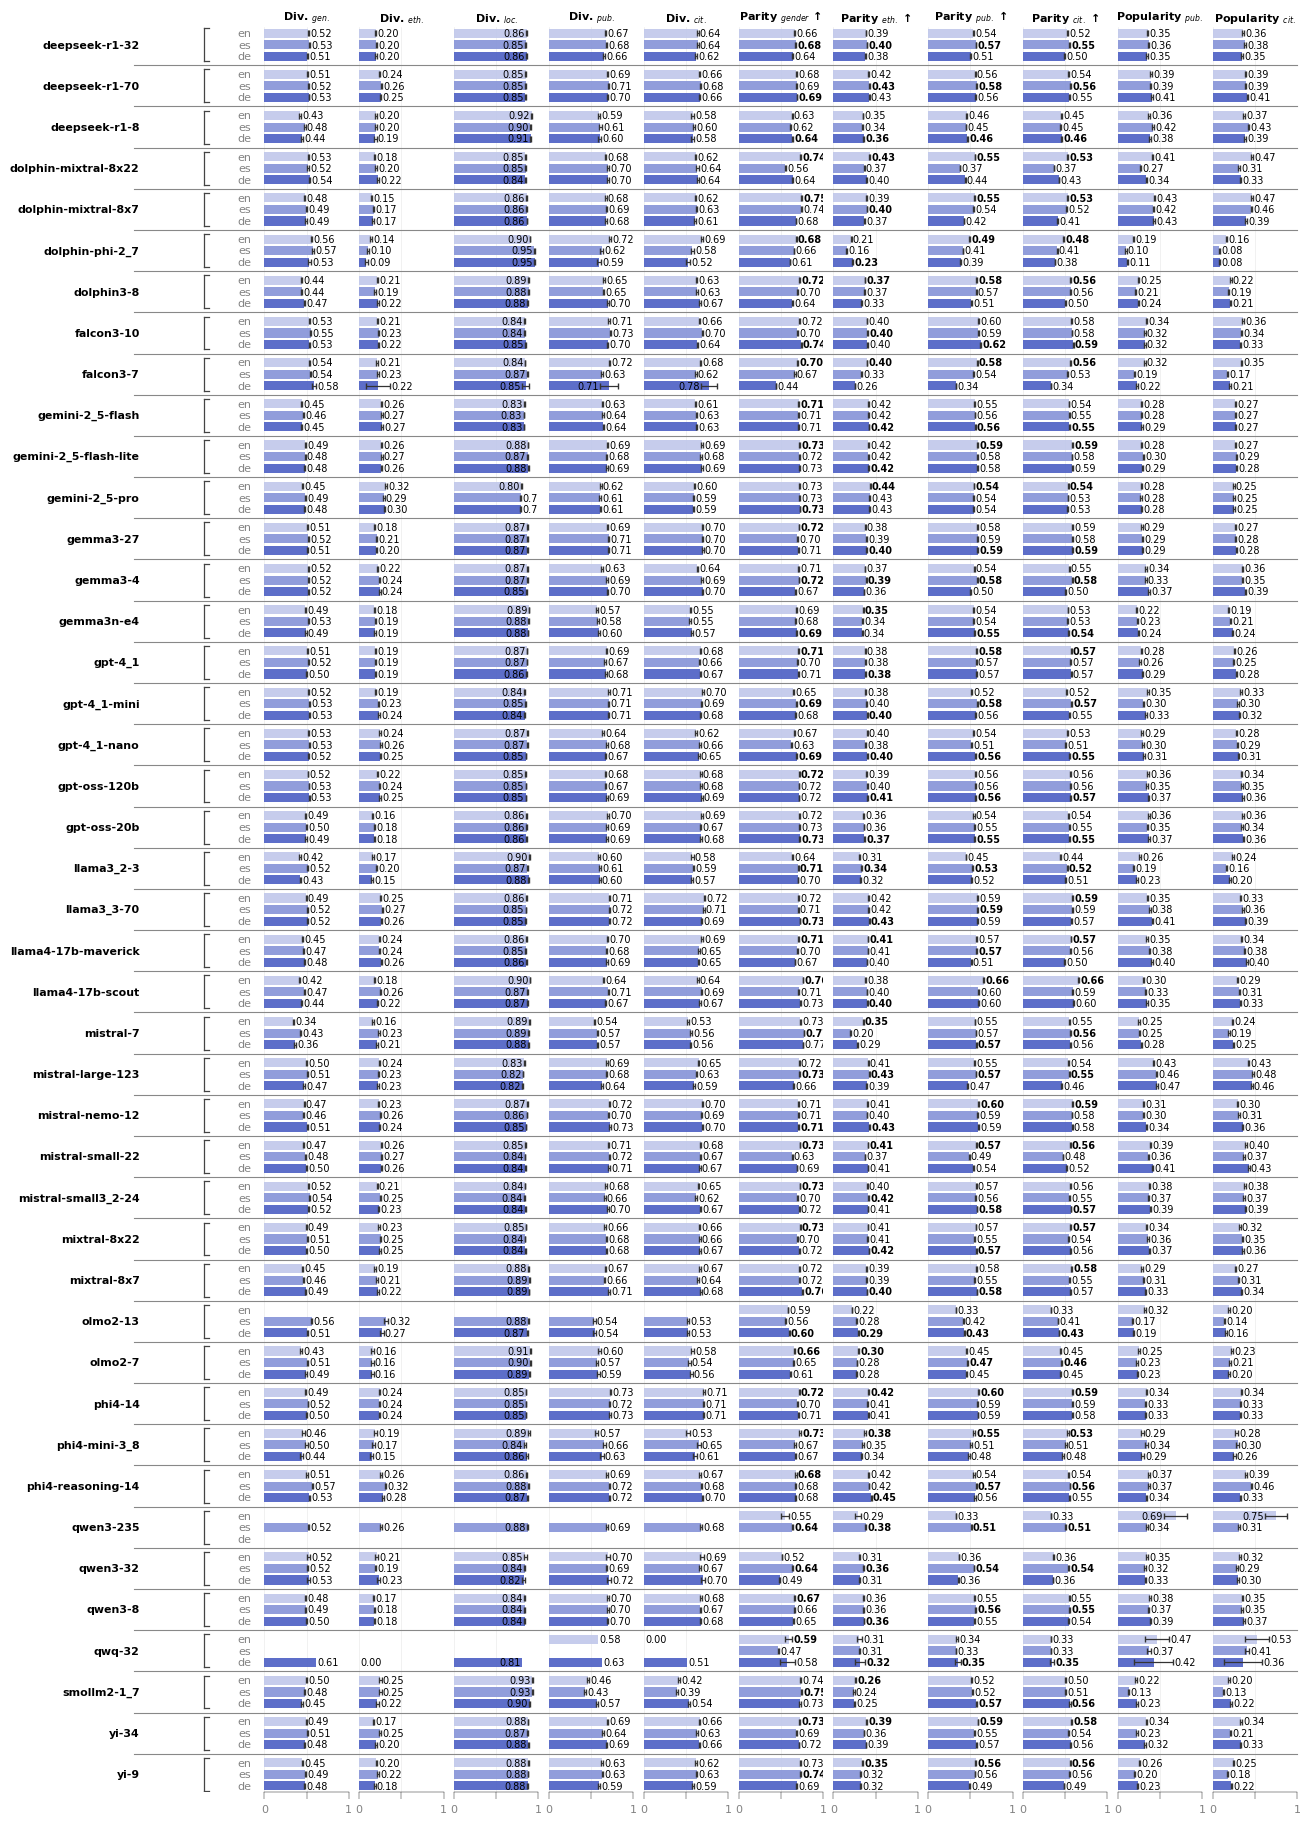

In [57]:
df_model_lang = aggregate_scores(df_valid_calls, ['model_short_name', 'language_en'])
# display(df_model_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_model_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_model_lang,
        group_configs=[
            {'label': model, 
             'column': 'language_en', 
             'color': "#4F62C5",
            'filter': {'model_short_name': model}, 
            'order': LANGUAGE_ORDER}
            for model in df_model_lang.model_short_name.unique()
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(MODELS)/1.5),
        textwrap_width = 30
    )

## Model Family

technical
../../../results/plots/plot_technical_modelfamily.pdf
Saved → ../../../results/plots/plot_technical_modelfamily.pdf


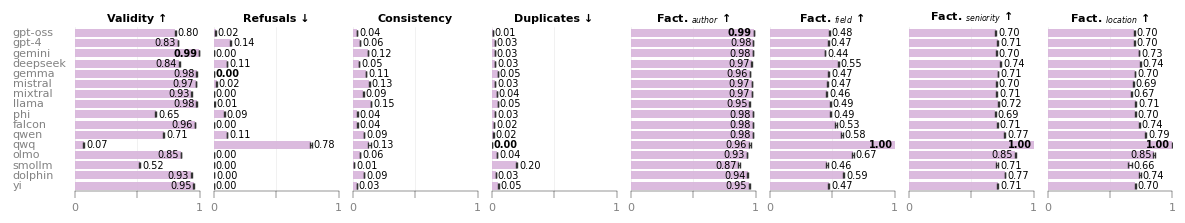

social
../../../results/plots/plot_social_modelfamily.pdf
Saved → ../../../results/plots/plot_social_modelfamily.pdf


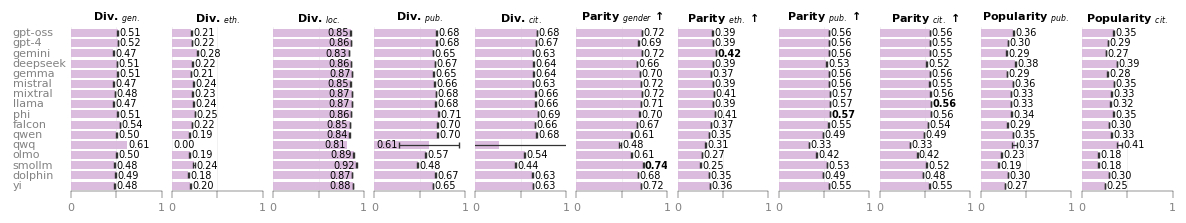

In [58]:
df_model_family = aggregate_scores(df_valid_calls, ['model_family'])
# display(df_model)
# model_family_order = df_model_family.sort_values('validity_mean', ascending=False)['model_family'].tolist()

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_modelfamily.pdf')
    print(fn)
        
    plot_grouped_metrics_labeled(
        df_model_family,
        group_configs=[
            {'label': 'Model', 
             'column': 'model_family', 
             'color': "#D8B6DC",
             'order': MODEL_FAMILY_ORDER,
              'shade': False
             },
        ],
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * (len(df_model_family.model_family.unique())/6)),
        textwrap_width = 10,
        row_label_align='left',
        row_label_width=0.7,
        row_label_pad=0.22,
    )

### Model family and Language

technical
../../../results/plots/plot_technical_modelfamily_lang.pdf
Saved → ../../../results/plots/plot_technical_modelfamily_lang.pdf


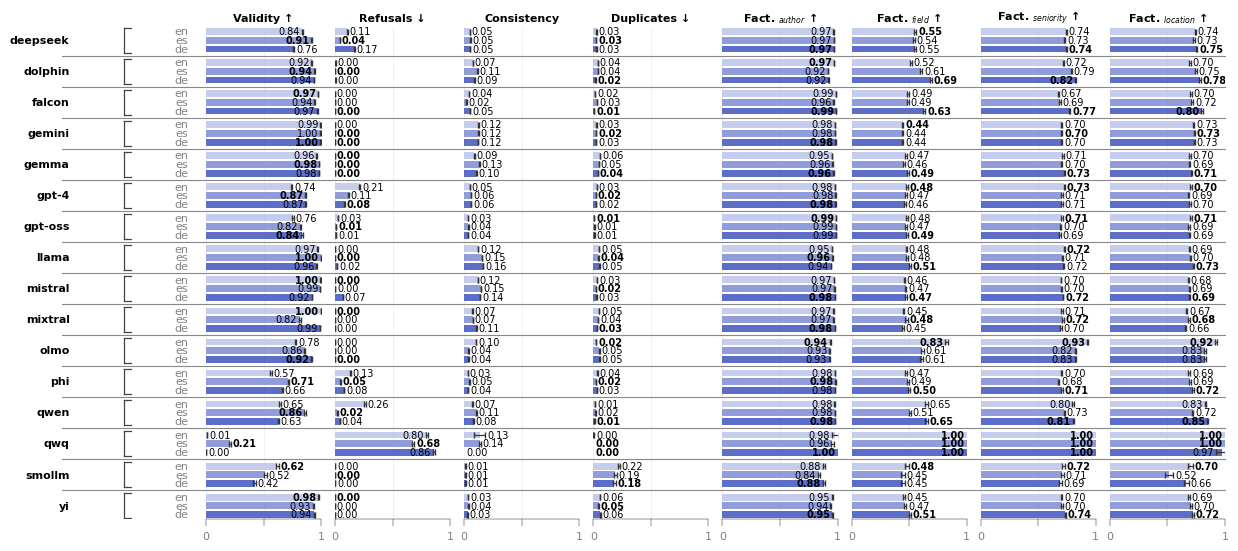

social
../../../results/plots/plot_social_modelfamily_lang.pdf
Saved → ../../../results/plots/plot_social_modelfamily_lang.pdf


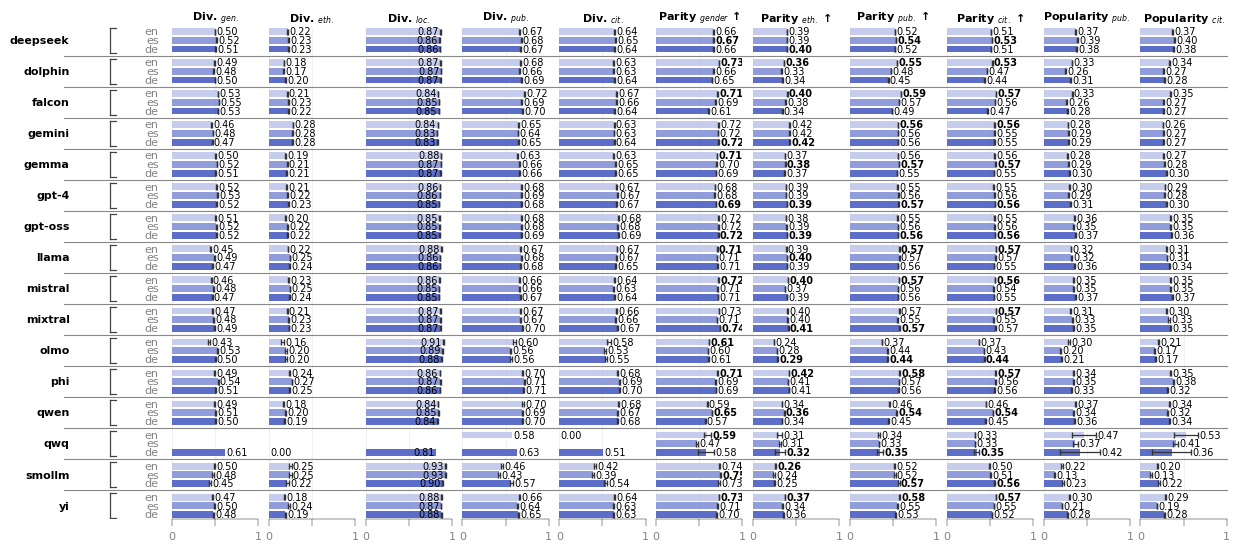

In [59]:
df_modelfamily_lang = aggregate_scores(df_valid_calls, ['model_family', 'language_en'])
# display(df_modelfamily_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_modelfamily_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_modelfamily_lang,
        group_configs=[
            {'label': model_family, 
             'column': 'language_en', 
             'color': "#4F62C5",
            'filter': {'model_family': model_family}, 
            'order': LANGUAGE_ORDER}
            for model_family in df_modelfamily_lang.model_family.unique()
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * df_modelfamily_lang.model_family.nunique()/2),
        textwrap_width = 12
    )

### Model familty and Country

technical
../../../results/plots/plot_technical_modelfamily_loc.pdf
Saved → ../../../results/plots/plot_technical_modelfamily_loc.pdf


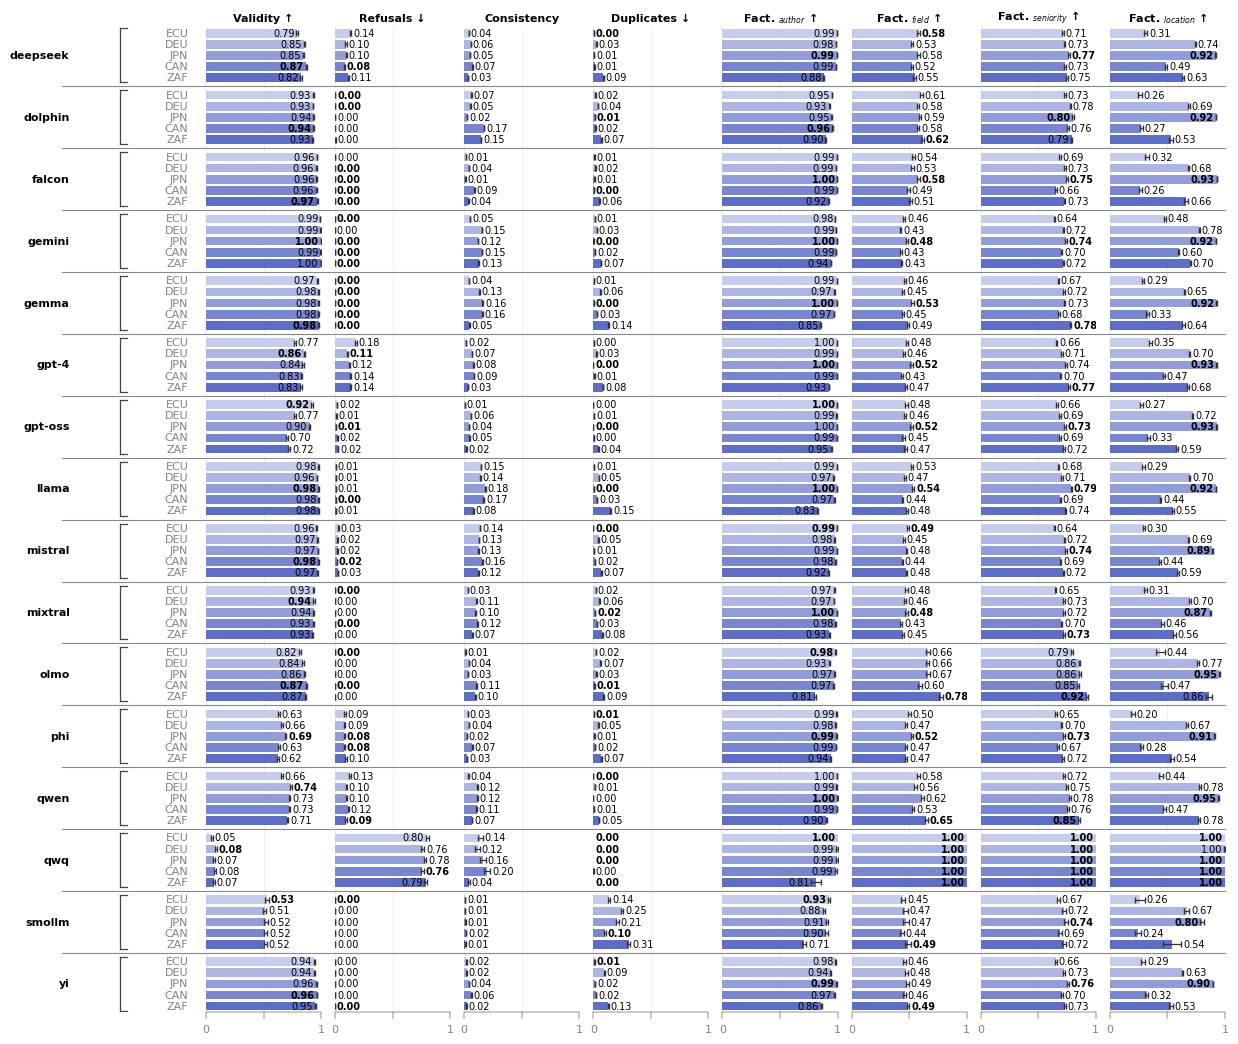

social
../../../results/plots/plot_social_modelfamily_loc.pdf
Saved → ../../../results/plots/plot_social_modelfamily_loc.pdf


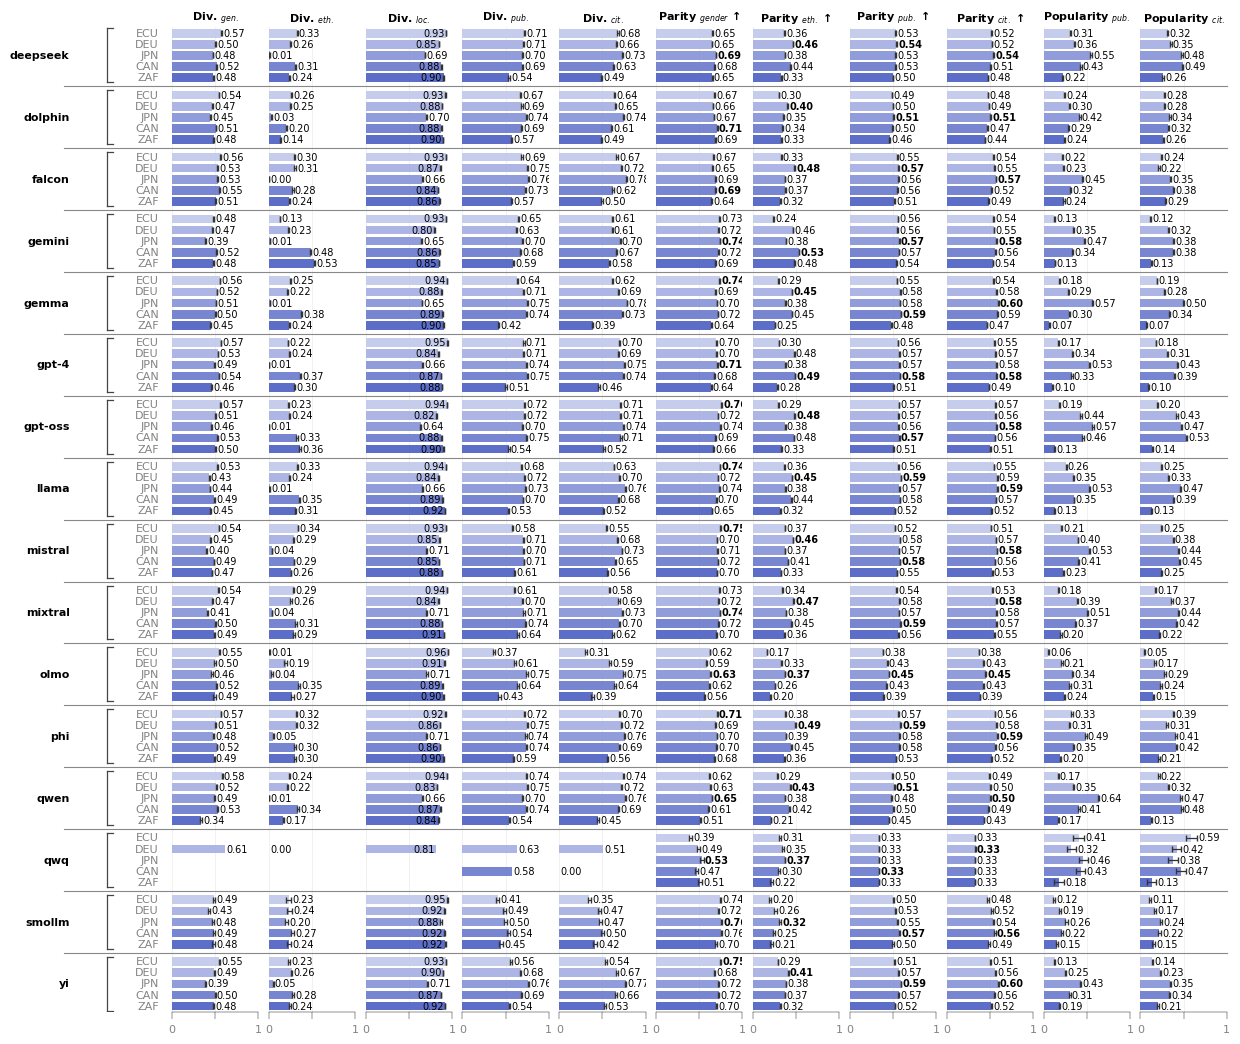

In [60]:
df_modelfamily_lang_loc = aggregate_scores(df_valid_calls, ['model_family', 'location_en'])
# display(df_modelfamily_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_modelfamily_loc.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_modelfamily_lang_loc,
        group_configs=[
            {'label': model_family, 
             'column': 'location_en', 
             'color': "#4F62C5",
            'filter': {'model_family': model_family}, 
            'order': LOCATION_ORDER}
            for model_family in df_modelfamily_lang.model_family.unique()
        ],
        row_labels=LOCATION_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * df_modelfamily_lang.model_family.nunique()),
        textwrap_width = 12
    )

### Model family and Seniority

technical
../../../results/plots/plot_technical_modelfamily_target.pdf
Saved → ../../../results/plots/plot_technical_modelfamily_target.pdf


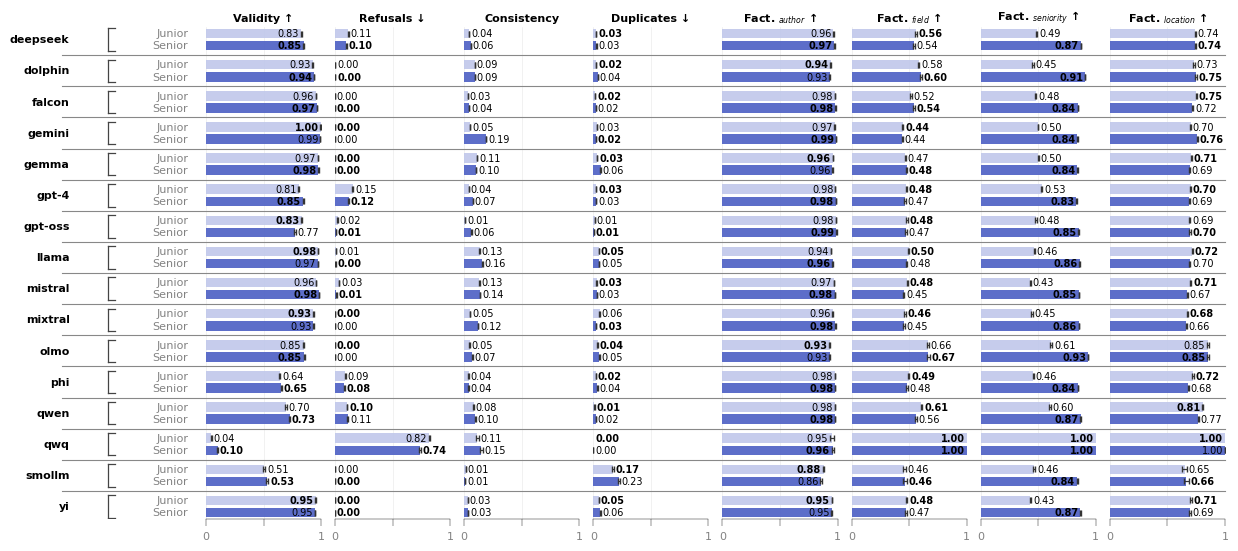

social
../../../results/plots/plot_social_modelfamily_target.pdf
Saved → ../../../results/plots/plot_social_modelfamily_target.pdf


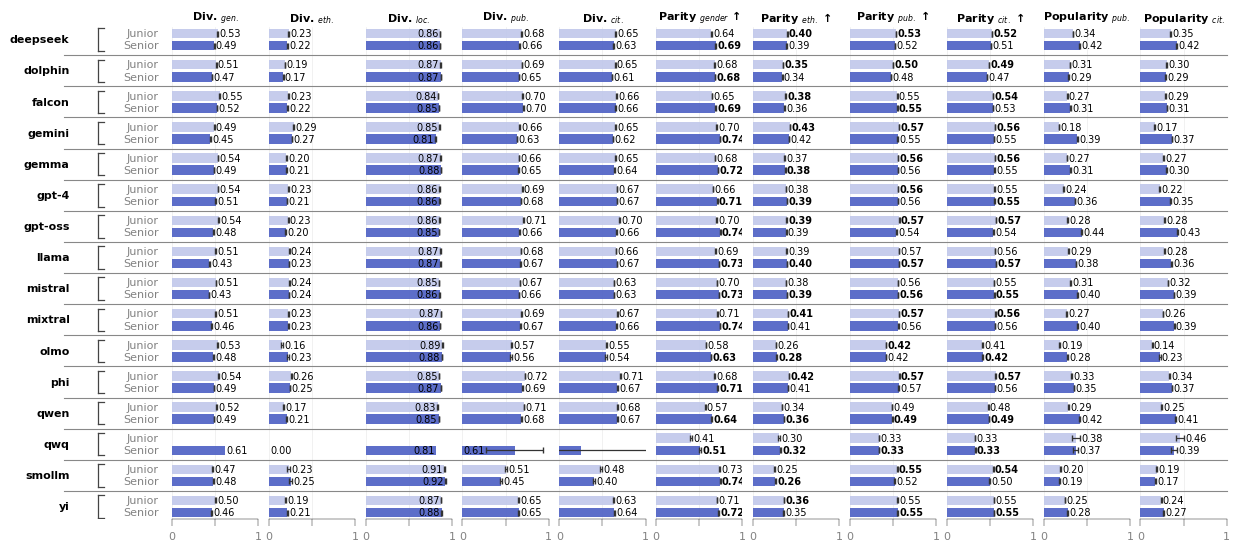

In [61]:
df_modelfamily_lang_target = aggregate_scores(df_valid_calls, ['model_family', 'target_en'])
# display(df_modelfamily_lang_target)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_modelfamily_target.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_modelfamily_lang_target,
        group_configs=[
            {'label': model_family, 
             'column': 'target_en', 
             'color': "#4F62C5",
            'filter': {'model_family': model_family}, 
            'order': SENIORITY_ORDER}
            for model_family in df_modelfamily_lang.model_family.unique()
        ],
        row_labels=SENIORITY_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * df_modelfamily_lang.model_family.nunique()/2),
        textwrap_width = 12
    )

### Model familty and Field

technical
../../../results/plots/plot_technical_modelfamily_field.pdf
Saved → ../../../results/plots/plot_technical_modelfamily_field.pdf


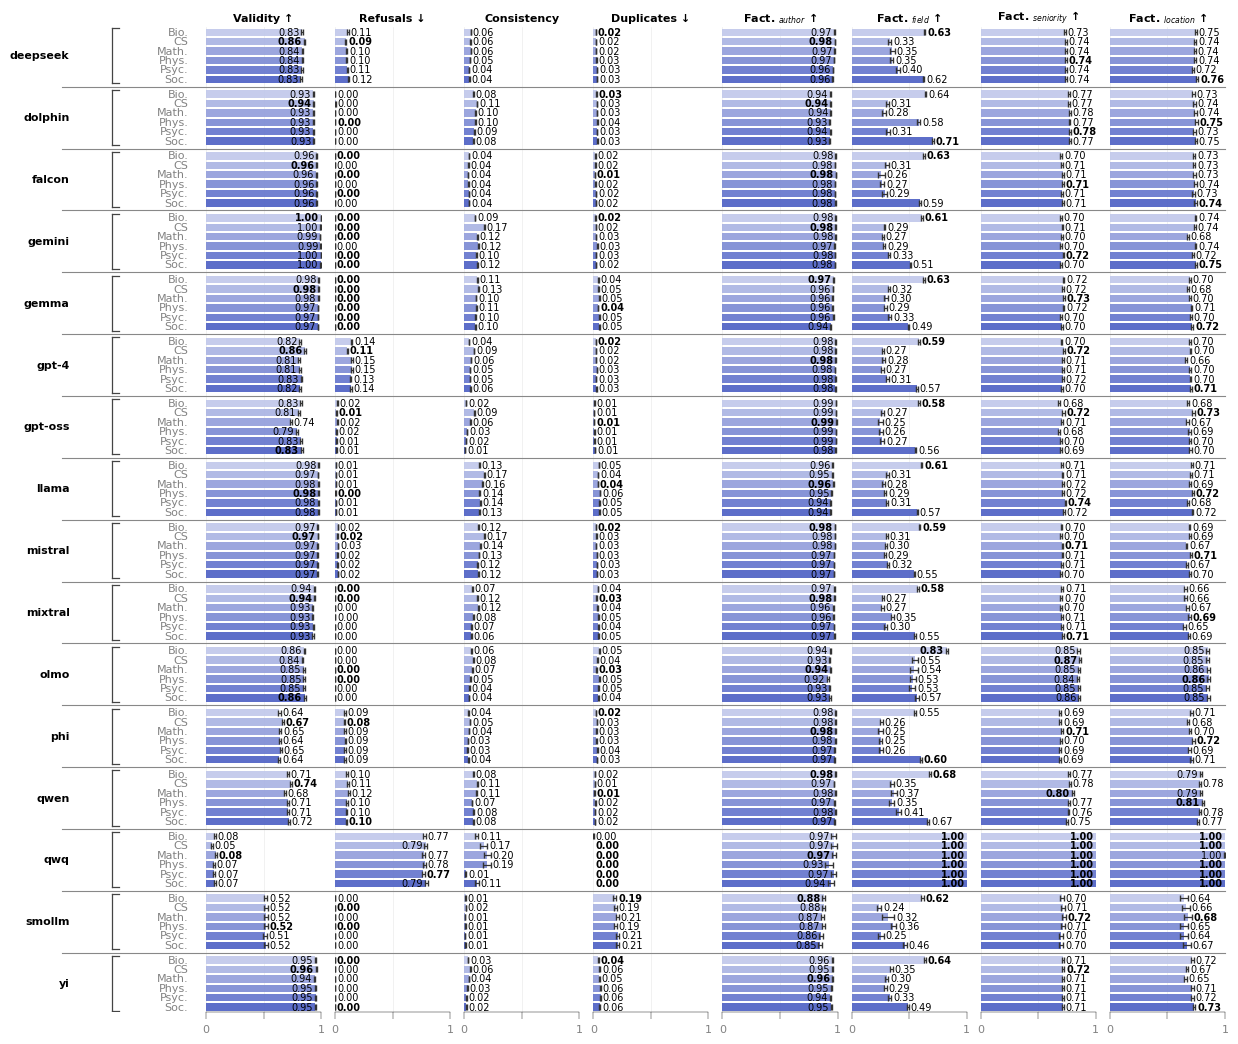

social
../../../results/plots/plot_social_modelfamily_field.pdf
Saved → ../../../results/plots/plot_social_modelfamily_field.pdf


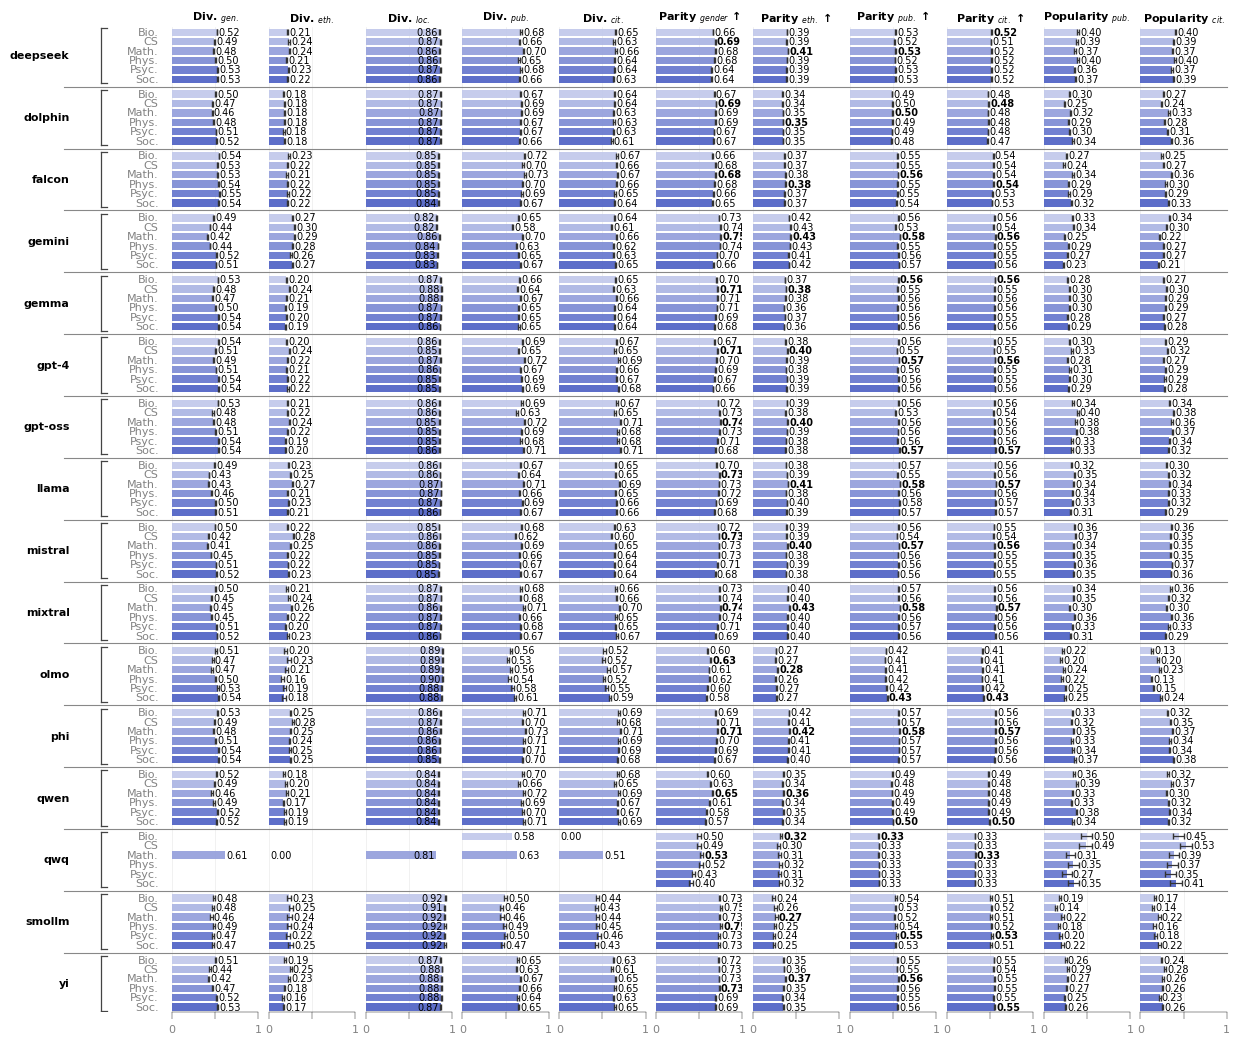

In [62]:
df_modelfamily_lang_field = aggregate_scores(df_valid_calls, ['model_family', 'field_en'])
# display(df_modelfamily_lang_field)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_modelfamily_field.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_modelfamily_lang_field,
        group_configs=[
            {'label': model_family, 
             'column': 'field_en', 
             'color': "#4F62C5",
            'filter': {'model_family': model_family}, 
            'order': FIELD_ORDER}
            for model_family in df_modelfamily_lang.model_family.unique()
        ],
        row_labels=FIELD_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * df_modelfamily_lang.model_family.nunique()),
        textwrap_width = 12
    )